# IDM Data Analysis

This notebook analyzes annual default-count data using three benchmark models:

- Torri
- Lo–Davis
- Vasicek

It includes i.i.d. fits, hierarchical extensions, model comparison, variance decomposition,
and tail-risk diagnostics used to reproduce the figures in the paper.


## Setup and core utilities
Load packages, fix the random seed, and define numerically stable helper functions used throughout the notebook.

In [ ]:
# =========================
# Setup
# =========================
import random
import math
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

from IPython.display import display
from math import lgamma
from scipy.optimize import minimize, minimize_scalar, brentq
from scipy.stats import norm, multivariate_normal
from numpy.polynomial.hermite import hermgauss

SEED = 123
random.seed(SEED)
np.random.seed(SEED)

# =========================
# Setup
# =========================
# =========================
# Numeric utilities
# =========================

def log_comb(n: int, k: int) -> float:
    """log( n choose k )"""
    return lgamma(n+1) - lgamma(k+1) - lgamma(n-k+1)

def logsumexp_arr(logw: np.ndarray) -> float:
    """stable log(sum(exp(logw))) for 1D array"""
    m = np.max(logw)
    if np.isneginf(m):
        return -np.inf
    return m + np.log(np.sum(np.exp(logw - m)))

def logsumexp(x: float, y: float) -> float:
    """log(exp(x)+exp(y))"""
    m = max(x, y)
    if np.isneginf(m):
        return -np.inf
    return m + np.log(np.exp(x-m) + np.exp(y-m))

def logsubexp(a: float, b: float) -> float:
    """log(exp(a)-exp(b)) with a>b; otherwise -inf"""
    if b >= a:
        return -np.inf
    return a + np.log1p(-np.exp(b - a))

def normalize_logpmf(logpmf: np.ndarray) -> np.ndarray:
    """Normalize log-PMF array to PMF (handles -inf safely)."""
    logpmf = np.where(np.isfinite(logpmf), logpmf, -np.inf)
    m = np.max(logpmf)
    if not np.isfinite(m):
        return np.full_like(logpmf, np.nan, dtype=float)
    z = np.sum(np.exp(logpmf - m))
    return np.exp(logpmf - (m + np.log(z)))

# =========================
# Tail & moments utilities
# =========================

def var_from_pmf(pmf: np.ndarray, alpha: float = 0.99, side: str = "left") -> int:
    """VaRα = inf{h: P(L<=h) >= α}."""
    cdf = np.cumsum(pmf)
    return int(np.searchsorted(cdf, alpha, side=side))

def es_from_pmf(pmf: np.ndarray, var_h: int, strict: bool = False) -> float:
    """
    ESα: default is E[L | L >= VaRα] (strict=False).
    strict=True -> E[L | L > VaRα]
    """
    pmf = np.asarray(pmf, dtype=float)
    x = np.arange(len(pmf))
    start = var_h + 1 if strict else var_h
    tail = pmf[start:]
    tp = tail.sum()
    if tp <= 0:
        return np.nan
    return float((x[start:] * tail).sum() / tp)

def moments_from_pmf(pmf: np.ndarray):
    x = np.arange(len(pmf))
    mean = float((x*pmf).sum())
    var = float(((x-mean)**2 * pmf).sum())
    return mean, var

def m_rho_from_pmf(pmf: np.ndarray):
    """Return (m, rho, Var(L)) where m=E[L]/n, rho is pairwise default corr (exchangeable proxy)."""
    pmf = np.asarray(pmf, dtype=float)
    s = pmf.sum()
    if s <= 0:
        return np.nan, np.nan, np.nan
    pmf = pmf / s

    n = len(pmf) - 1
    x = np.arange(n+1)

    EL  = float((x * pmf).sum())
    EL2 = float(((x**2) * pmf).sum())
    varL = EL2 - EL**2

    if n <= 0:
        return np.nan, np.nan, varL

    m = EL / n
    denom = n*(n-1)*m*(1-m)
    if denom <= 1e-15:
        return m, np.nan, varL

    rho = (varL - n*m*(1-m)) / denom
    return m, rho, varL

def survival_from_pmf(pmf: np.ndarray) -> np.ndarray:
    """S[h] = P(L >= h)"""
    return np.flip(np.cumsum(np.flip(pmf)))

def tail_metrics_from_pmf(pmf: np.ndarray, alpha: float = 0.99, strict_es: bool = False):
    v = var_from_pmf(pmf, alpha=alpha)
    e = es_from_pmf(pmf, v, strict=strict_es)
    return dict(
        VaR=v,
        ES=e,
        ES_minus_VaR=(e - v) if np.isfinite(e) else np.nan,
        ES_over_VaR=(e / v) if (np.isfinite(e) and v > 0) else np.nan
    )

# Torri Model
def pmf_Torri(n: int, p: float, u: float, v: float) -> np.ndarray:
    """
    Torri (infectious default) PMF for L_n.
    Numerically stable (log-sum-exp).
    """
    a = p*(1-v)
    b = (1-p)*(1-u)
    c = (1-p)*u
    bc = b + c  # = 1-p

    pmf_log = np.full(n+1, -np.inf, dtype=float)

    log_bc = -np.inf if bc <= 0 else np.log(bc)

    for h in range(n+1):
        # term0 = a^h * (b+c)^(n-h)
        if h == 0:
            log_a_h = 0.0
        else:
            log_a_h = -np.inf if a <= 0 else h*np.log(a)
        log_term0 = log_a_h + (n-h)*log_bc

        # term1 = ((p+b)^h - (a+b)^h) * c^(n-h)
        if h == 0:
            log_term1 = -np.inf
        else:
            # c^(n-h)
            if (n-h) == 0:
                log_c_pow = 0.0
            else:
                log_c_pow = -np.inf if c <= 0 else (n-h)*np.log(c)

            X = p + b
            Y = a + b

            if log_c_pow == -np.inf or X <= 0 or Y <= 0:
                log_term1 = -np.inf
            else:
                logXh = h*np.log(X)
                logYh = h*np.log(Y)
                log_diff = logsubexp(logXh, logYh)
                log_term1 = -np.inf if log_diff == -np.inf else (log_diff + log_c_pow)

        pmf_log[h] = log_comb(n, h) + logsumexp2(log_term0, log_term1)

    return normalize_logpmf(pmf_log)

def moments_from_params_Torri(n: int, p: float, u: float, v: float):
    """Closed-form (m, rho) for Torri parameterization used in this notebook."""
    b = (1-p)*(1-u)
    s = 1 - p*v

    # mean (fraction)
    m = p + b*(1 - s**(n-1))

    # pair moment term
    a_alt = s + p - 1
    s_pow = s**(n-2) if n > 2 else 1.0
    E = (p+b)**2 - b*(2*a_alt + b)*s_pow

    cov = E - m**2
    den = m*(1-m)
    rho = np.nan if den <= 1e-15 else cov/den
    return float(m), float(rho)

# Lo-Davis Model
def pmf_LD(n: int, p: float, q: float) -> np.ndarray:
    """
    Lo–Davis Infectious Default Model PMF via mixture:
      K ~ Bin(n,p), L|K=k = k + Bin(n-k, r_k), r_k = 1 - (1-q)^k
    Stable implementation using expm1/log1p and log-sum-exp.
    """
    if not (0.0 <= p <= 1.0 and 0.0 <= q <= 1.0):
        raise ValueError("p and q must be in [0,1].")

    # log P(K=k)
    logP_K = np.full(n+1, -np.inf, dtype=float)
    if p == 0.0:
        logP_K[0] = 0.0
    elif p == 1.0:
        logP_K[n] = 0.0
    else:
        log_p = np.log(p)
        log_1mp = np.log1p(-p)
        for k in range(n+1):
            logP_K[k] = log_comb(n, k) + k*log_p + (n-k)*log_1mp

    # r_k = 1 - (1-q)^k  (stable)
    r = np.zeros(n+1, dtype=float)
    if q == 0.0:
        r[:] = 0.0
    elif q == 1.0:
        r[0] = 0.0
        r[1:] = 1.0
    else:
        l = np.log1p(-q)
        ks = np.arange(n+1, dtype=float)
        r = -np.expm1(ks * l)

    pmf_log = np.full(n+1, -np.inf, dtype=float)

    for h in range(n+1):
        # sum over k=0..h
        terms = np.full(h+1, -np.inf, dtype=float)
        for k in range(h+1):
            if not np.isfinite(logP_K[k]):
                continue
            t = h - k
            nk = n - k
            rk = r[k]
            if t < 0 or t > nk:
                continue

            if rk == 0.0:
                if t != 0:
                    continue
                log_bin = 0.0
            elif rk == 1.0:
                if t != nk:
                    continue
                log_bin = 0.0
            else:
                log_rk = np.log(rk)
                log_1mrk = np.log1p(-rk)
                log_bin = log_comb(nk, t) + t*log_rk + (nk-t)*log_1mrk

            terms[k] = logP_K[k] + log_bin

        pmf_log[h] = logsumexp_arr(terms)

    return normalize_logpmf(pmf_log)

def m_rho_LD(n: int, p: float, q: float):
    """
    Closed-form (m, rhoZ) for Lo–Davis.
    m = 1 - (1-p)*(1-qp)^(n-1)
    Cov = (1-p)^2 * [ (1 - 2pq + p q^2)^(n-2) - (1-pq)^(2(n-1)) ]
    rho = Cov / (m(1-m))
    """
    m = 1.0 - (1.0 - p) * (1.0 - q*p)**(n-1)
    if n < 2:
        return float(m), np.nan
    termA = (1.0 - 2.0*p*q + p*(q**2))**(n-2)
    termB = (1.0 - p*q)**(2*(n-1))
    cov = (1.0 - p)**2 * (termA - termB)
    var = m*(1.0-m)
    rho = cov/var if var > 1e-15 else np.nan
    return float(m), float(rho)

def check_mrho_formula_vs_pmf_LD(n: int, p: float, q: float):
    pmf = pmf_LD(n, p, q)
    m_pmf, rho_pmf, _ = m_rho_from_pmf(pmf)
    m_f, rho_f = m_rho_LD(n, p, q)
    return dict(m_pmf=m_pmf, m_formula=m_f, diff_m=m_pmf-m_f,
                rho_pmf=rho_pmf, rho_formula=rho_f, diff_rho=rho_pmf-rho_f,
                pmf_sum=float(pmf.sum()))

# Vasicek Model
def phi2_aa(a: float, rhoA: float) -> float:
    cov = np.array([[1.0, rhoA],
                    [rhoA, 1.0]])
    return float(multivariate_normal.cdf([a, a], mean=[0.0, 0.0], cov=cov))

def default_corr_from_asset_corr(m: float, rhoA: float) -> float:
    a = norm.ppf(m)
    q = phi2_aa(a, rhoA)
    return float((q - m*m) / (m*(1.0 - m)))

def invert_asset_corr_from_default_corr(m: float, rho_target: float, tol: float = 1e-10) -> float:
    """Solve rhoA in [0, 0.999999] such that Corr(Zi,Zj)=rho_target."""
    if not (0.0 < m < 1.0):
        raise ValueError("m must be in (0,1).")
    if not (-1.0 < rho_target < 1.0):
        raise ValueError("rho_target must be in (-1,1).")

    def F(rhoA):
        return default_corr_from_asset_corr(m, rhoA) - rho_target

    return float(brentq(F, 0.0, 0.999999, xtol=tol, rtol=tol, maxiter=200))

def pmf_Vas(n: int, m: float, rhoA: float, n_gh: int = 60) -> np.ndarray:
    """
    L|Y=y ~ Bin(n, p(y)), p(y)=Phi((a - sqrt(rhoA)*y)/sqrt(1-rhoA))
    PMF = E[ BinPMF(h; n, p(Y)) ] using Gauss-Hermite + log-sum-exp.
    """
    a = norm.ppf(m)
    s = np.sqrt(rhoA)
    t = np.sqrt(1.0 - rhoA)

    x, w = hermgauss(n_gh)
    y = np.sqrt(2.0) * x
    log_w = np.log(w) - 0.5*np.log(np.pi)

    p = norm.cdf((a - s*y) / t)
    p = np.clip(p, 1e-15, 1.0 - 1e-15)
    logp = np.log(p)
    log1mp = np.log1p(-p)

    hs = np.arange(n+1)
    logC = np.array([log_comb(n, h) for h in hs], dtype=float)

    log_bin = logC[None, :] + hs[None, :]*logp[:, None] + (n-hs)[None, :]*log1mp[:, None]
    log_terms = log_w[:, None] + log_bin

    m0 = np.max(log_terms, axis=0)
    pmf = np.exp(m0 + np.log(np.sum(np.exp(log_terms - m0[None, :]), axis=0)))

    pmf = np.maximum(pmf, 0.0)
    pmf = pmf / pmf.sum()
    return pmf

# Data loading
url = "./M_1920_2023.csv"
df = pd.read_csv(url)

display(df.head())
display(df.tail())
print(df.columns)
print(df.shape)

,Year,SG,D_SG,IG,D_IG,ALL,D_ALL
0,1920,831,25,1843,8,2674,33
1,1921,1163,25,1833,7,2996,32
2,1922,1305,23,1972,10,3277,33
3,1923,1290,22,2068,5,3358,27
4,1924,1297,37,2175,3,3472,40


,Year,SG,D_SG,IG,D_IG,ALL,D_ALL
99,2019,3002,96,3400,2,6402,98
100,2020,2964,205,3452,2,6416,207
101,2021,2909,51,3470,0,6379,51
102,2022,3148,135,3529,17,6677,152
103,2023,2961,143,3496,4,6457,147


Index(['Year', 'SG', 'D_SG', 'IG', 'D_IG', 'ALL', 'D_ALL'], dtype='object')
(104, 7)


## Summary statistics
Compute basic class-level summary statistics for exposure counts and default rates.

In [2]:
# =========================
# Summary statistics
# =========================

def summarize_nt_default(df, label):
    n = df[label].to_numpy(dtype=float)
    L = df["D_" + label].to_numpy(dtype=float)

    return {
        "Class": label,
        "Mean n": np.mean(n),
        "Mean L": np.mean(L),
        "Mean default rate": np.mean(L / n),
        "Total default rate": np.sum(L) / np.sum(n),
    }

summary = pd.DataFrame([
    summarize_nt_default(df, "ALL"),
    summarize_nt_default(df, "SG"),
    summarize_nt_default(df, "IG"),
])

# Sort order
summary = summary.set_index("Class").loc[["ALL", "SG", "IG"]]

# Display (rounded)
summary_rounded = summary.round({
    "Mean n": 1,
    "Mean L": 2,
    "Mean default rate": 4,
    "Total default rate": 4
})

summary_rounded

,Mean n,Mean L,Mean default rate,Total default rate
Class,,,,
ALL,2572.6,40.30,0.0120,0.0157
SG,1007.7,38.12,0.0288,0.0378
IG,1564.9,2.17,0.0014,0.0014


## Subperiod summary statistics
Split the sample into 1950–1979 and 1980–2023 and compare summary statistics across periods.

In [3]:
# =========================
# Restrict sample period to 1950-2023
# =========================
df_sub = df[(df["Year"] >= 1950) & (df["Year"] <= 2023)].copy()

# Period split
df_sub["period"] = np.where(
    df_sub["Year"] <= 1979,
    "1950-1979",
    "1980-2023"
)

def summarize_nt_default_by_period(df, label):
    out = []
    for period in ["1950-1979", "1980-2023"]:
        g = df[df["period"] == period]

        n = g[label].to_numpy(dtype=float)
        L = g["D_" + label].to_numpy(dtype=float)

        out.append({
            "Class": label,
            "Period": period,
            "Mean n": np.mean(n),
            "Mean L": np.mean(L),
            "Mean default rate": np.mean(L / n),
            "Total default rate": np.sum(L) / np.sum(n),
        })
    return out

rows = []
for cls in ["ALL", "SG", "IG"]:
    rows.extend(summarize_nt_default_by_period(df_sub, cls))

summary_period = pd.DataFrame(rows)

# Sorting
summary_period = summary_period.set_index(["Class", "Period"]).loc[
    pd.MultiIndex.from_product(
        [["ALL", "SG", "IG"], ["1950-1979", "1980-2023"]],
        names=["Class", "Period"]
    )
]

# Display (rounded)
summary_period_rounded = summary_period.round({
    "Mean n": 1,
    "Mean L": 2,
    "Mean default rate": 4,
    "Total default rate": 4
})

summary_period_rounded

Mean n  Mean L  Mean default rate  Total default rate
Class Period                                                          
ALL   1950-1979   860.2    2.53             0.0026              0.0029
      1980-2023  4276.4   71.86             0.0157              0.0168
SG    1950-1979   240.0    2.37             0.0093              0.0099
      1980-2023  1678.4   69.32             0.0416              0.0413
IG    1950-1979   620.2    0.17             0.0002              0.0003
      1980-2023  2598.0    2.55             0.0009              0.0010

## Default-rate time series
Plot annual default rates for ALL, SG, and IG, with the early period highlighted.

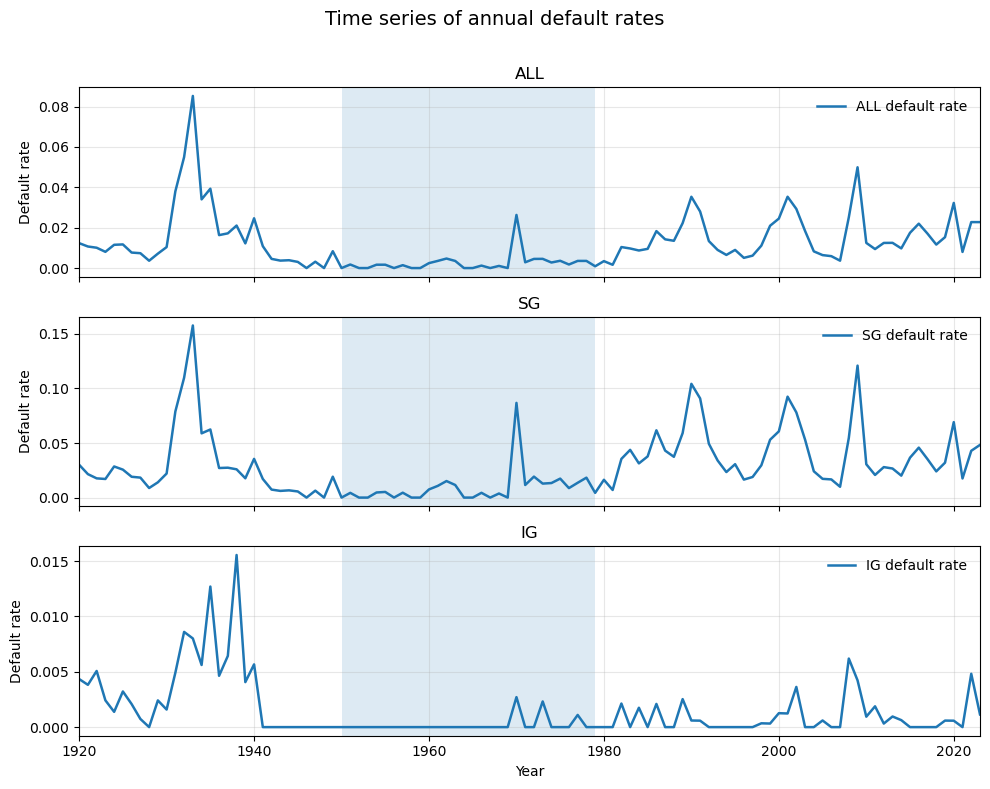

In [4]:
# =========================
# Time-series plot of default rates
#   - 3 panels: ALL / SG / IG
#   - shaded early period: 1950-1979
# =========================

# Required columns:
# df["Year"], df["ALL"], df["D_ALL"], df["SG"], df["D_SG"], df["IG"], df["D_IG"]

# Ensure year is numeric
df["Year"] = pd.to_numeric(df["Year"])

# Construct default rates
for cls in ["ALL", "SG", "IG"]:
    df[f"rate_{cls}"] = df[f"D_{cls}"] / df[cls]

# Plot settings
classes = ["ALL", "SG", "IG"]
titles = {
    "ALL": "ALL",
    "SG": "SG",
    "IG": "IG",
}

fig, axes = plt.subplots(
    nrows=3, ncols=1, figsize=(10, 8), sharex=True
)

for ax, cls in zip(axes, classes):
    ax.axvspan(1950, 1979, alpha=0.15)

    # Time series
    ax.plot(
        df["Year"],
        df[f"rate_{cls}"],
        linewidth=1.8,
        label=f"{cls} default rate"
    )

    # Styling
    ax.set_ylabel("Default rate")
    ax.set_title(titles[cls], fontsize=12)
    ax.grid(True, alpha=0.3)
    ax.legend(frameon=False, loc="upper right")

axes[-1].set_xlabel("Year")
axes[-1].set_xlim(df["Year"].min(), df["Year"].max())

fig.suptitle("Time series of annual default rates", fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.97])
# Save figure
fig.savefig("figure7_default_rate_timeseries.pdf", bbox_inches="tight")
plt.show()

## Torri model: PMF and i.i.d. fit
Define the Torri log-PMF and related fitting routines under the i.i.d. specification.

In [5]:
def log_pmf_Torri(n: int, h: int, p: float, u: float, v: float) -> float:
    # constraints (p strictly inside to avoid log(0) issues in bc=1-p)
    if not (0.0 < p < 1.0 and 0.0 <= u <= 1.0 and 0.0 <= v <= 1.0):
        return -np.inf
    if not (0 <= h <= n):
        return -np.inf

    a = p*(1.0 - v)
    b = (1.0 - p)*(1.0 - u)
    c = (1.0 - p)*u
    bc = b + c  # = 1-p

    # --- term0 = a^h * (b+c)^(n-h) ---
    # log term0
    if h > 0:
        if a <= 0.0:
            t0 = -np.inf
        else:
            t0 = h*math.log(a) + (n-h)*math.log(bc)
    else:
        # a^0 = 1
        t0 = (n-h)*math.log(bc)

    # --- term1 = ((p+b)^h - (a+b)^h) * c^(n-h) ---
    pb = p + b
    ab = a + b

    if h == 0:
        t1 = -np.inf
    else:
        # if v=0 -> a=p -> pb==ab -> difference 0
        if pb <= 0.0 or ab <= 0.0:
            t1 = -np.inf
        else:
            lp = h*math.log(pb)
            la = h*math.log(ab)

            # stable log(exp(lp)-exp(la)) (requires lp>la)
            diff_log = logsubexp(lp, la)
            if diff_log == -np.inf:
                t1 = -np.inf
            else:
                if (n-h) > 0:
                    if c <= 0.0:
                        t1 = -np.inf
                    else:
                        t1 = diff_log + (n-h)*math.log(c)
                else:
                    t1 = diff_log

    # combine
    inner = logsumexp(t0, t1)
    if inner == -np.inf:
        return -np.inf

    return log_comb(n, h) + inner

def fit_one_Torri(series_n, series_h, x0=None, maxiter=5000):
    data = np.c_[series_n.to_numpy(dtype=int), series_h.to_numpy(dtype=int)]

    def neg_ll_torri(theta):
        # unconstrained -> (0,1) via sigmoid
        p = 1.0/(1.0 + np.exp(-theta[0]))
        u = 1.0/(1.0 + np.exp(-theta[1]))
        v = 1.0/(1.0 + np.exp(-theta[2]))

        ll = 0.0
        for n, h in data:
            lp = log_pmf_Torri(int(n), int(h), float(p), float(u), float(v))
            if not np.isfinite(lp):
                return 1e100
            ll += lp
        return -ll

    # initial guess (logit)
    if x0 is None:
        x0 = np.array([
            math.log(0.01/0.99),  # p ~ 1%
            math.log(0.9/0.1),    # u ~ 0.9
            math.log(0.1/0.9),    # v ~ 0.1
        ], dtype=float)

    res = minimize(neg_ll_torri, x0, method="Nelder-Mead", options={"maxiter": maxiter})

    th = res.x
    p = 1.0/(1.0 + np.exp(-th[0]))
    u = 1.0/(1.0 + np.exp(-th[1]))
    v = 1.0/(1.0 + np.exp(-th[2]))
    return {
        "p": float(p), "u": float(u), "v": float(v),
        "nll": float(res.fun),
        "success": bool(res.success),
        "nit": int(res.nit),
        "message": str(res.message),
    }

# ALL
out_all_Torri = fit_one_Torri(df["ALL"], df["D_ALL"])
print("ALL Torri fit:", out_all_Torri)

# SG / IG
out_sg_Torri = fit_one_Torri(df["SG"], df["D_SG"])
out_ig_Torri = fit_one_Torri(df["IG"], df["D_IG"])
print("SG  Torri fit:", out_sg_Torri)
print("IG  Torri fit:", out_ig_Torri)

ALL Torri fit: {'p': 0.008401151137753948, 'u': 0.980004675944488, 'v': 0.014121693332986157, 'nll': 725.8290833779024, 'success': True, 'nit': 87, 'message': 'Optimization terminated successfully.'}
SG  Torri fit: {'p': 0.0222510616322509, 'u': 0.9524321287077615, 'v': 0.01181877861793521, 'nll': 643.2579759702968, 'success': True, 'nit': 92, 'message': 'Optimization terminated successfully.'}
IG  Torri fit: {'p': 0.0013886154534263142, 'u': 0.5844129082879481, 'v': 6.783619917074998e-14, 'nll': 290.27846864202536, 'success': True, 'nit': 130, 'message': 'Optimization terminated successfully.'}


## Lo–Davis model: PMF and i.i.d. fit
Define the Lo–Davis log-PMF and estimation helpers under the i.i.d. specification.

In [6]:
def logsumexp_vec(logw):
    m = np.max(logw)
    if np.isneginf(m):
        return -np.inf
    return float(m + np.log(np.sum(np.exp(logw - m))))

def log_pmf_LD_1pt(n, h, p, q):
    """
    LD mixture:
      K ~ Bin(n,p)
      L|K=k = k + Bin(n-k, r_k),  r_k = 1 - (1-q)^k
    Return log P(L=h) by summing over k=0..h
    """
    if not (0 <= h <= n):
        return -np.inf

    # numerical guards
    eps = 1e-15
    p = float(np.clip(p, eps, 1.0 - eps))
    q = float(np.clip(q, eps, 1.0 - eps))

    log_p  = math.log(p)
    log_1p = math.log1p(-p)
    log_1q = math.log1p(-q)

    terms = np.full(h+1, -np.inf, dtype=float)

    for k in range(0, h+1):
        t = h - k
        nk = n - k
        if t < 0 or t > nk:
            continue

        # log P(K=k)
        log_pk = log_comb(n, k) + k*log_p + (n-k)*log_1p

        # r_k = 1 - (1-q)^k  (stable)
        if k == 0:
            if t != 0:
                continue
            log_bin = 0.0
        else:
            rk = -math.expm1(k * log_1q)  # stable 1-(1-q)^k
            # handle extreme rk
            if rk <= 0.0:
                if t != 0:
                    continue
                log_bin = 0.0
            elif rk >= 1.0:
                if t != nk:
                    continue
                log_bin = 0.0
            else:
                log_r  = math.log(rk)
                log_1r = math.log1p(-rk)
                log_bin = log_comb(nk, t) + t*log_r + (nk-t)*log_1r

        terms[k] = log_pk + log_bin

    return logsumexp_vec(terms)

def fit_one_LD(series_n, series_h):
    tmp = pd.DataFrame({"n": series_n.to_numpy(dtype=int),
                        "h": series_h.to_numpy(dtype=int)})
    g = tmp.value_counts().reset_index(name="cnt")
    n_arr = g["n"].to_numpy(dtype=int)
    h_arr = g["h"].to_numpy(dtype=int)
    c_arr = g["cnt"].to_numpy(dtype=int)

    def neg_ll_ld(theta):
        p = 1/(1+np.exp(-theta[0]))
        q = 1/(1+np.exp(-theta[1]))

        ll = 0.0
        for n, h, c in zip(n_arr, h_arr, c_arr):
            lp = log_pmf_LD_1pt(int(n), int(h), float(p), float(q))
            if not np.isfinite(lp):
                return 1e100
            ll += c * lp
        return -ll

    x0 = np.array([math.log(0.01/0.99), math.log(0.02/0.98)])
    res = minimize(neg_ll_ld, x0, method="Nelder-Mead", options={"maxiter":8000})

    th = res.x
    p = 1/(1+np.exp(-th[0]))
    q = 1/(1+np.exp(-th[1]))
    return {
        "p": float(p), "q": float(q),
        "nll": float(res.fun),
        "success": bool(res.success),
        "nit": int(res.nit),
        "message": str(res.message),
    }

# quick consistency check
#n = int(df["ALL"].iloc[0])
#p, q = 0.01, 0.02
#pmf = pmf_LD(n, p, q)
#for h in [0, 1, 2, 5, 10]:
#    a = math.log(pmf[h]) if pmf[h] > 0 else -np.inf
#    b = log_pmf_LD_1pt(n, h, p, q)
#    print(h, a, b, a-b)

# Lo-Davis fit dictionaries
out_all_ld = fit_one_LD(df["ALL"], df["D_ALL"])
out_sg_ld  = fit_one_LD(df["SG"],  df["D_SG"])
out_ig_ld  = fit_one_LD(df["IG"],  df["D_IG"])

print("ALL LD fit:", out_all_ld)
print("SG  LD fit:", out_sg_ld)
print("IG  LD fit:", out_ig_ld)

ALL LD fit: {'p': 0.0011255669412148428, 'q': 0.0037846636855538925, 'nll': 461.21619874089686, 'success': True, 'nit': 43, 'message': 'Optimization terminated successfully.'}
SG  LD fit: {'p': 0.002804201013741565, 'q': 0.009240830177675394, 'nll': 441.99826145607597, 'success': True, 'nit': 38, 'message': 'Optimization terminated successfully.'}
IG  LD fit: {'p': 0.0004600371841217707, 'q': 0.001014146775969712, 'nll': 194.5175579704115, 'success': True, 'nit': 41, 'message': 'Optimization terminated successfully.'}


## Vasicek model: PMF and i.i.d. fit
Define the Vasicek log-PMF using Gauss–Hermite quadrature and estimate the i.i.d. model.

In [7]:
# =========================
# Vasicek (GH_N fixed = 100): log P(L_n=h | p, rho_A) + i.i.d. MLE
# =========================
# p = unconditional default probability

GH_N = 100
gh_x, gh_w = hermgauss(GH_N)

def log_pmf_Vas_1pt(n: int, h: int, p: float, rho_A: float) -> float:
    if not (0 <= h <= n):
        return -np.inf

    eps = 1e-15
    p = float(np.clip(p, eps, 1.0 - eps))
    rho_A = float(np.clip(rho_A, eps, 1.0 - 1e-12))

    a  = norm.ppf(p)
    sr = math.sqrt(rho_A)
    tr = math.sqrt(1.0 - rho_A)

    logC = log_comb(n, h)

    # guard invalid GH weights (should be fine up to ~200, but harmless)
    mask = np.isfinite(gh_w) & (gh_w > 0) & np.isfinite(gh_x)
    x = gh_x[mask]
    w = gh_w[mask]
    if len(w) == 0:
        return -np.inf

    log_terms = np.empty(len(w), dtype=float)

    for i, (xi, wi) in enumerate(zip(x, w)):
        z  = math.sqrt(2.0) * float(xi)
        pi = norm.cdf((a - sr*z) / tr)
        pi = float(np.clip(pi, eps, 1.0 - eps))

        log_bin = logC + h*math.log(pi) + (n-h)*math.log1p(-pi)
        log_terms[i] = math.log(float(wi)) + log_bin

    return logsumexp_vec(log_terms) - 0.5*math.log(math.pi)

def fit_one_Vas(series_n, series_h, x0=None, maxiter=8000):
    tmp = pd.DataFrame({
        "n": series_n.to_numpy(dtype=int),
        "h": series_h.to_numpy(dtype=int),
    })
    g = tmp.value_counts().reset_index(name="cnt")
    n_arr = g["n"].to_numpy(dtype=int)
    h_arr = g["h"].to_numpy(dtype=int)
    c_arr = g["cnt"].to_numpy(dtype=int)

    def neg_ll_vas(theta):
        p     = 1.0/(1.0 + np.exp(-theta[0]))
        rho_A = 1.0/(1.0 + np.exp(-theta[1]))

        ll = 0.0
        for n, h, c in zip(n_arr, h_arr, c_arr):
            lp = log_pmf_Vas_1pt(int(n), int(h), float(p), float(rho_A))
            if not np.isfinite(lp):
                return 1e100
            ll += int(c) * lp
        return -ll

    if x0 is None:
        x0 = np.array([math.log(0.01/0.99), math.log(0.05/0.95)], dtype=float)

    res = minimize(neg_ll_vas, x0, method="Nelder-Mead", options={"maxiter": maxiter})

    th = res.x
    p     = 1.0/(1.0 + np.exp(-th[0]))
    rho_A = 1.0/(1.0 + np.exp(-th[1]))

    return {
        "p": float(p),
        "rho_A": float(rho_A),
        "nll": float(res.fun),
        "success": bool(res.success),
        "nit": int(res.nit),
        "message": str(res.message),
        "GH_N": int(GH_N),
    }

# ---- fits ----
out_all_vas = fit_one_Vas(df["ALL"], df["D_ALL"])
out_sg_vas  = fit_one_Vas(df["SG"],  df["D_SG"])
out_ig_vas  = fit_one_Vas(df["IG"],  df["D_IG"])

print("ALL Vasicek fit:", out_all_vas)
print("SG  Vasicek fit:", out_sg_vas)
print("IG  Vasicek fit:", out_ig_vas)

ALL Vasicek fit: {'p': 0.011775206606779358, 'rho_A': 0.13557728347067463, 'nll': 431.3637107991922, 'success': True, 'nit': 35, 'message': 'Optimization terminated successfully.', 'GH_N': 100}
SG  Vasicek fit: {'p': 0.030365528141289545, 'rho_A': 0.14959676685401402, 'nll': 417.7085349993006, 'success': True, 'nit': 45, 'message': 'Optimization terminated successfully.', 'GH_N': 100}
IG  Vasicek fit: {'p': 0.0016138196765759921, 'rho_A': 0.2000063051072147, 'nll': 182.38168605536418, 'success': True, 'nit': 35, 'message': 'Optimization terminated successfully.', 'GH_N': 100}


## i.i.d. model comparison table
Collect fitted parameters and negative log-likelihood values for the three benchmark models.

In [8]:
# =========================
# Summary table: Torri / LD / Vas(GH_N=100)
# =========================

def to_float_dict(d):
    out = {}
    for k, v in d.items():
        try:
            out[k] = float(v)
        except Exception:
            out[k] = v
    return out

rows = []

# --- Torri ---
rows.append({**{"model":"Torri", "class":"ALL"}, **to_float_dict(out_all_Torri)})
rows.append({**{"model":"Torri", "class":"SG"},  **to_float_dict(out_sg_Torri)})
rows.append({**{"model":"Torri", "class":"IG"},  **to_float_dict(out_ig_Torri)})

# --- LD ---
rows.append({**{"model":"LD", "class":"ALL"}, **to_float_dict(out_all_ld)})
rows.append({**{"model":"LD", "class":"SG"},  **to_float_dict(out_sg_ld)})
rows.append({**{"model":"LD", "class":"IG"},  **to_float_dict(out_ig_ld)})

# --- Vasicek (GH_N=100) ---
rows.append({**{"model":"Vas", "class":"ALL"}, **to_float_dict(out_all_vas)})
rows.append({**{"model":"Vas", "class":"SG"},  **to_float_dict(out_sg_vas)})
rows.append({**{"model":"Vas", "class":"IG"},  **to_float_dict(out_ig_vas)})

df_fit = pd.DataFrame(rows)

# column order (missing columns are ignored)
col_order = [
    "model","class","nll",
    "p","u","v",
    "q",
    "rho_A",
    "success","nit","message","GH_N"
]
df_fit = df_fit[[c for c in col_order if c in df_fit.columns]]

# nice sorting
df_fit = df_fit.sort_values(["class","model"]).reset_index(drop=True)

df_fit.round(6)

,model,class,nll,p,u,v,q,rho_A,success,nit,message,GH_N
0,LD,ALL,461.216199,0.001126,NaN,NaN,0.003785,NaN,1.0,43.0,Optimization terminated successfully.,NaN
1,Torri,ALL,725.829083,0.008401,0.980005,0.014122,NaN,NaN,1.0,87.0,Optimization terminated successfully.,NaN
2,Vas,ALL,431.363711,0.011775,NaN,NaN,NaN,0.135577,1.0,35.0,Optimization terminated successfully.,100.0
3,LD,IG,194.517558,0.000460,NaN,NaN,0.001014,NaN,1.0,41.0,Optimization terminated successfully.,NaN
4,Torri,IG,290.278469,0.001389,0.584413,0.000000,NaN,NaN,1.0,130.0,Optimization terminated successfully.,NaN
5,Vas,IG,182.381686,0.001614,NaN,NaN,NaN,0.200006,1.0,35.0,Optimization terminated successfully.,100.0
6,LD,SG,441.998261,0.002804,NaN,NaN,0.009241,NaN,1.0,38.0,Optimization terminated successfully.,NaN
7,Torri,SG,643.257976,0.022251,0.952432,0.011819,NaN,NaN,1.0,92.0,Optimization terminated successfully.,NaN
8,Vas,SG,417.708535,0.030366,NaN,NaN,NaN,0.149597,1.0,45.0,Optimization terminated successfully.,100.0


## Shared helper functions
Define transformation, cleaning, and aggregation utilities reused in later sections.

In [9]:
# ==========================================
# Common helpers (define ONCE)
# ==========================================

def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))

def softplus(x):
    return np.log1p(np.exp(-np.abs(x))) + np.maximum(x, 0.0)

def inv_softplus(s):
    s = float(s)
    if s <= 0:
        raise ValueError("softplus inverse requires s > 0")
    return s + np.log(-np.expm1(-s))

def _clean_nh(series_n, series_h):
    tmp = pd.DataFrame({
        "n": series_n.to_numpy(dtype=int),
        "h": series_h.to_numpy(dtype=int),
    })
    tmp = tmp[(tmp["n"] > 0) & (tmp["h"] >= 0) & (tmp["h"] <= tmp["n"])].copy()
    return tmp

def make_grouped_nh(series_n, series_h):
    tmp = _clean_nh(series_n, series_h)
    g = tmp.value_counts().reset_index(name="cnt")
    n_arr = g["n"].to_numpy(dtype=int)
    h_arr = g["h"].to_numpy(dtype=int)
    c_arr = g["cnt"].to_numpy(dtype=int)
    return n_arr, h_arr, c_arr

def _clean_nL(df, key):
    n_vals = df[key].astype(int).to_numpy()
    L_vals = df["D_" + key].astype(int).to_numpy()
    mask = (
        (n_vals > 0) &
        (L_vals >= 0) &
        (L_vals <= n_vals) &
        np.isfinite(n_vals) &
        np.isfinite(L_vals)
    )
    return n_vals[mask].astype(int), L_vals[mask].astype(int)

def scaled_counts(n_vals, L_vals, nbar):
    n_vals = np.asarray(n_vals, dtype=float)
    L_vals = np.asarray(L_vals, dtype=float)
    Ls = np.rint(L_vals * (float(nbar) / n_vals)).astype(int)
    Ls = np.maximum(Ls, 0)
    return Ls

def gh_normal_weights(mu, sigma, GH_N):
    x, w = hermgauss(int(GH_N))
    y = mu + math.sqrt(2.0) * sigma * x
    wn = w / math.sqrt(math.pi)
    wn = wn / np.sum(wn)
    return y, wn

def aggregate_m_q_to_rho(m, q):
    den = m * (1.0 - m)
    if den <= 1e-15:
        return float("nan")
    return (q - m * m) / den

def torri_m_q_for_n(n, p, u, v):
    b = (1.0 - p) * (1.0 - u)
    s = 1.0 - p * v
    a = p * (1.0 - v)
    m = p + b * (1.0 - s**(n - 1)) if n >= 1 else 0.0
    q_pair = (p + b)**2 - b * (2.0 * a + b) * (s**(n - 2)) if n >= 2 else m * m
    return float(m), float(q_pair)

def build_compare_decomp_table(out_var_hier_ld, out_var_hier_torri):
    cols = [
        "class",
        "Share_iid_within_model",
        "Share_infect_within_model",
        "Share_pt_within_model",
        "Iid_over_VarData",
        "Infect_over_VarData",
        "Pt_over_VarData",
    ]
    df_ld = out_var_hier_ld[cols].copy()
    df_ld["model"] = "Lo–Davis"
    df_t = out_var_hier_torri[cols].copy()
    df_t["model"] = "Torri"
    df_cmp = pd.concat([df_ld, df_t], axis=0, ignore_index=True)
    return df_cmp.sort_values(["class", "model"]).reset_index(drop=True)

## Fixed-*n* visualization
Compare fitted distributions on a common fixed portfolio size for clearer cross-model visualization.

In [10]:
# ==========================================
# Fixed-n visualization:
#  - Fit uses real (n_t, L_t)
#  - Plot uses fixed nbar per class
#  - Data are scaled: L_scaled = round(L_t * nbar / n_t)
# Models: Torri / Lo–Davis / Vasicek(GH_N=100)
# ==========================================

# --- collect fitted params (use your existing outputs) ---
fits_torri = {
    "ALL": {"p": float(out_all_Torri["p"]), "u": float(out_all_Torri["u"]), "v": float(out_all_Torri["v"])},
    "SG":  {"p": float(out_sg_Torri["p"]),  "u": float(out_sg_Torri["u"]),  "v": float(out_sg_Torri["v"])},
    "IG":  {"p": float(out_ig_Torri["p"]),  "u": float(out_ig_Torri["u"]),  "v": float(out_ig_Torri["v"])},
}
fits_ld = {
    "ALL": {"p": float(out_all_ld["p"]), "q": float(out_all_ld["q"])},
    "SG":  {"p": float(out_sg_ld["p"]),  "q": float(out_sg_ld["q"])},
    "IG":  {"p": float(out_ig_ld["p"]),  "q": float(out_ig_ld["q"])},
}
fits_vas = {
    "ALL": {"p": float(out_all_vas["p"]), "rho_A": float(out_all_vas["rho_A"])},
    "SG":  {"p": float(out_sg_vas["p"]),  "rho_A": float(out_sg_vas["rho_A"])},
    "IG":  {"p": float(out_ig_vas["p"]),  "rho_A": float(out_ig_vas["rho_A"])},
}

# --- class-wise average nbar (given / or compute from df) ---
NBAR = {
    "ALL": 2573,
    "SG":  1008,
    "IG":  1565,
}

def empirical_pmf_from_counts(Ls):
    Ls = np.asarray(Ls, dtype=int)
    hmax = int(Ls.max())
    h = np.arange(hmax + 1)
    hist, _ = np.histogram(Ls, bins=np.arange(hmax + 2) - 0.5, density=True)
    return h, hist

def model_pmf_fixed_n(model, key, nbar, hmax):
    h = np.arange(hmax + 1, dtype=int)

    if model == "Torri":
        p,u,v = fits_torri[key]["p"], fits_torri[key]["u"], fits_torri[key]["v"]
        lp = np.full(hmax + 1, -np.inf, dtype=float)
        h_ok = h[h <= nbar]
        lp[h_ok] = np.array([log_pmf_Torri(int(nbar), int(x), float(p), float(u), float(v)) for x in h_ok], dtype=float)
        pmf = normalize_logpmf(lp)
        return pmf

    if model == "LD":
        p,q = fits_ld[key]["p"], fits_ld[key]["q"]
        lp = np.full(hmax + 1, -np.inf, dtype=float)
        h_ok = h[h <= nbar]
        lp[h_ok] = np.array([log_pmf_LD_1pt(int(nbar), int(x), float(p), float(q)) for x in h_ok], dtype=float)
        pmf = normalize_logpmf(lp)
        return pmf

    if model == "Vas":
        p,rhoA = fits_vas[key]["p"], fits_vas[key]["rho_A"]
        lp = np.full(hmax + 1, -np.inf, dtype=float)
        h_ok = h[h <= nbar]
        lp[h_ok] = np.array([log_pmf_Vas_1pt(int(nbar), int(x), float(p), float(rhoA)) for x in h_ok], dtype=float)
        pmf = normalize_logpmf(lp)
        return pmf

## Plot style
Set plotting defaults for paper-style figures.

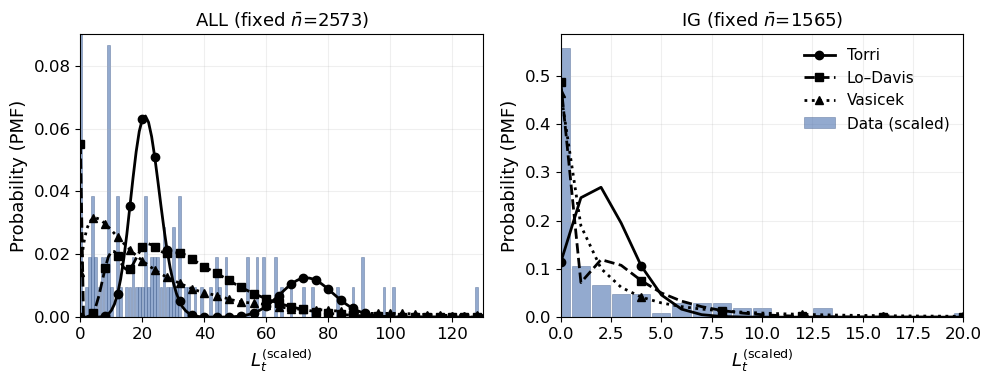

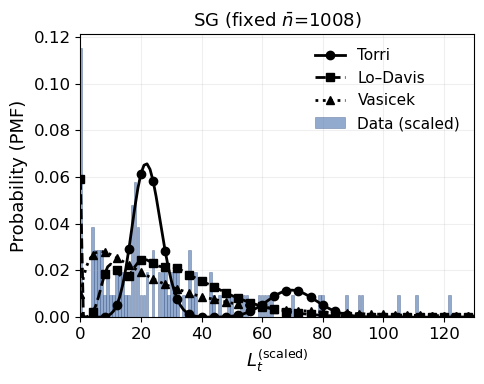

In [11]:
mpl.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 13,
    "axes.titlesize": 13,
    "legend.fontsize": 11,
    "lines.linewidth": 2.0,
    "savefig.dpi": 300,
})

NBAR = {
    "ALL": 2573,
    "SG":  1008,
    "IG":  1565,
}

model_styles = {
    "Torri": {"color": "black", "marker": "o", "linestyle": "-",  "markersize": 6, "markevery": 4},
    "LD":    {"color": "black", "marker": "s", "linestyle": "--", "markersize": 6, "markevery": 4},
    "Vas":   {"color": "black", "marker": "^", "linestyle": ":",  "markersize": 6, "markevery": 4},
}

data_style = {
    "color": "#4C72B0",
    "edgecolor": "#2F4B7C",
    "linewidth": 0.4,
    "alpha": 0.6
}

def plot_one(ax, key, show_legend=False):
    nbar = int(NBAR[key])
    n_vals = df[key].astype(int).values
    L_vals = df["D_" + key].astype(int).values

    Ls = np.rint(L_vals * (nbar / n_vals)).astype(int)
    Ls = np.maximum(Ls, 0)

    h = np.arange(Ls.max() + 1)
    hist, _ = np.histogram(Ls, bins=np.arange(len(h) + 1) - 0.5, density=True)

    ax.bar(h, hist, width=0.9, label="Data (scaled)", **data_style, zorder=1)

    hmax = int(h[-1])

    pmf_t = model_pmf_fixed_n("Torri", key, nbar, hmax)
    pmf_l = model_pmf_fixed_n("LD",    key, nbar, hmax)
    pmf_v = model_pmf_fixed_n("Vas",   key, nbar, hmax)

    ax.plot(h, pmf_t, label="Torri",    **model_styles["Torri"])
    ax.plot(h, pmf_l, label="Lo–Davis", **model_styles["LD"])
    ax.plot(h, pmf_v, label="Vasicek",  **model_styles["Vas"])

    ax.set_title(f"{key} (fixed $\\bar{{n}}$={nbar})")
    ax.set_xlabel(r"$L_t^{(\mathrm{scaled})}$")
    ax.set_ylabel("Probability (PMF)")
    ax.grid(alpha=0.2)

    if key == "ALL":
        ax.set_xlim(0, 130)
        ax.set_ylim(0, 0.09)
    elif key == "SG":
        ax.set_xlim(0, 130)
    elif key == "IG":
        ax.set_xlim(0, 20)

    if show_legend:
        ax.legend(frameon=False, loc="upper right")

# ==========================================
# (1) ALL + IG side by side
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, key in zip(axes, ["ALL", "IG"]):
    plot_one(ax, key, show_legend=(key == "IG"))

plt.tight_layout()
plt.savefig("figure2a_pmf_ALL_IG.pdf", bbox_inches="tight")
plt.show()

# ==========================================
# (2) SG only
# ==========================================
fig, ax = plt.subplots(figsize=(5, 4))
plot_one(ax, "SG", show_legend=True)
plt.tight_layout()
plt.savefig("figure8a_pmf_SG.pdf", bbox_inches="tight")
plt.show()

## Fixed-*n* visualization
Compare fitted distributions on a common fixed portfolio size for clearer cross-model visualization.

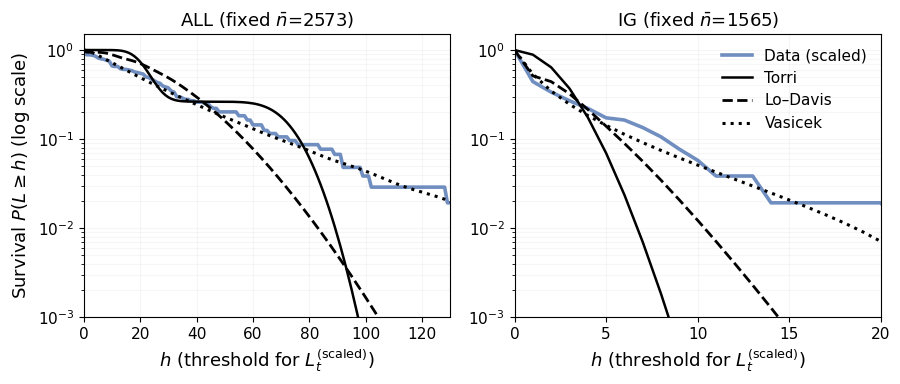

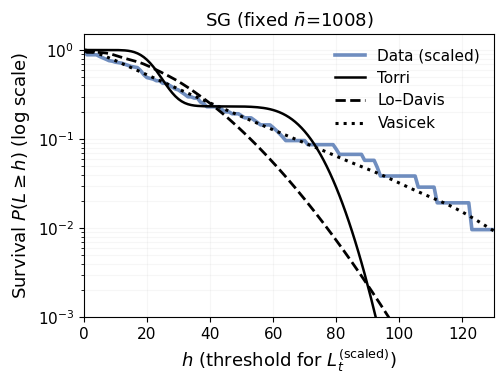

,class,alpha,model,VaR,ES,ES_minus_VaR,ES_over_VaR
0,ALL,0.95,Data (scaled),91,124.143,33.143,1.364
1,ALL,0.95,Lo–Davis,65,75.387,10.387,1.160
2,ALL,0.95,Torri,81,85.418,4.418,1.055
3,ALL,0.95,Vasicek,94,128.263,34.263,1.365
4,ALL,0.99,Data (scaled),141,180.000,39.000,1.277
5,ALL,0.99,Lo–Davis,83,91.936,8.936,1.108
6,ALL,0.99,Torri,89,92.162,3.162,1.036
7,ALL,0.99,Vasicek,153,178.780,25.780,1.168
8,IG,0.95,Data (scaled),10,15.000,5.000,1.500
9,IG,0.95,Lo–Davis,7,8.488,1.488,1.213


In [12]:
# ==========================================
# Survival (log-scale) + VaR/ES table
# Fixed-n visualization (scaled data)
# Models: Torri / Lo–Davis / Vasicek(GH_N=100)
# Generate 4 figures:
#   1) ALL + IG
#   2) ALL only
#   3) SG only
#   4) IG only
# ==========================================
ALPHAS = [0.95, 0.99]

mpl.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 13,
    "axes.titlesize": 13,
    "legend.fontsize": 11,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "lines.linewidth": 2.0,
    "savefig.dpi": 300,
})

# NBAR must include SG too
NBAR = {
    "ALL": 2573,
    "SG":  1008,
    "IG":  1565,
}

model_styles = {
    "Torri": {"color": "black", "ls": "-",  "lw": 1.8},
    "LD":    {"color": "black", "ls": "--", "lw": 2.0},
    "Vas":   {"color": "black", "ls": ":",  "lw": 2.2},
    "Data":  {"color": "#4C72B0", "ls": "-", "lw": 2.6, "alpha": 0.8},
}

# ==========================================
# helper: plot one survival panel
# ==========================================
def plot_survival_one(ax, key, show_legend=True):
    ax.set_facecolor("white")
    nbar = int(NBAR[key])
    n_vals = df[key].astype(int).values
    L_vals = df["D_" + key].astype(int).values

    Ls = scaled_counts(n_vals, L_vals, nbar)
    hmax = int(Ls.max())
    h = np.arange(hmax + 1, dtype=int)

    hist, _ = np.histogram(Ls, bins=np.arange(hmax + 2) - 0.5, density=True)
    S_data = survival_from_pmf(hist)

    pmf_t = model_pmf_fixed_n("Torri", key, nbar, hmax)
    pmf_l = model_pmf_fixed_n("LD",    key, nbar, hmax)
    pmf_v = model_pmf_fixed_n("Vas",   key, nbar, hmax)

    S_t = survival_from_pmf(pmf_t)
    S_l = survival_from_pmf(pmf_l)
    S_v = survival_from_pmf(pmf_v)

    eps = 1e-12
    ax.plot(h, np.maximum(S_data, eps), label="Data (scaled)", **model_styles["Data"])
    ax.plot(h, np.maximum(S_t, eps),    label="Torri",         **model_styles["Torri"])
    ax.plot(h, np.maximum(S_l, eps),    label="Lo–Davis",     **model_styles["LD"])
    ax.plot(h, np.maximum(S_v, eps),    label="Vasicek",      **model_styles["Vas"])

    ax.set_yscale("log")
    ax.set_title(f"{key} (fixed $\\bar{{n}}$={nbar})")
    ax.set_xlabel(r"$h$ (threshold for $L_t^{(\mathrm{scaled})}$)")
    ax.set_ylabel(r"Survival $P(L \geq h)$ (log scale)")
    ax.grid(alpha=0.1, which="both")
    ax.set_ylim(1e-3, 1.5)

    if key == "ALL":
        ax.set_xlim(0, 130)
    elif key == "SG":
        ax.set_xlim(0, 130)
    elif key == "IG":
        ax.set_xlim(0, 20)

    if show_legend:
        ax.legend(frameon=False, loc="upper right")

# ==========================================
# 1) ALL + IG (2 panels)
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(10.5, 4), sharex=False, sharey=False)

for ax, key in zip(axes, ["ALL", "IG"]):
    plot_survival_one(ax, key, show_legend=(key == "IG"))

# Keep the y-label only on the left panel if needed
axes[1].set_ylabel("")

plt.tight_layout(rect=[0, 0, 0.88, 1])
plt.savefig("figure2b_survival_ALL_IG.pdf", bbox_inches="tight")
plt.show()

# ==========================================
# 2) SG only
# ==========================================
fig, ax = plt.subplots(figsize=(5.2, 4))
plot_survival_one(ax, "SG", show_legend=True)
plt.tight_layout()
plt.savefig("figure8b_survival_SG.pdf", bbox_inches="tight")
plt.show()

# ==========================================
# 3) VaR / ES table (ALL, SG, IG)
# ==========================================
rows = []

for key in ["ALL", "SG", "IG"]:
    nbar = int(NBAR[key])
    n_vals = df[key].astype(int).values
    L_vals = df["D_" + key].astype(int).values
    Ls = scaled_counts(n_vals, L_vals, nbar)
    hmax = int(Ls.max())

    hist, _ = np.histogram(Ls, bins=np.arange(hmax + 2) - 0.5, density=True)
    pmf_data = np.maximum(hist, 0.0)
    pmf_data = pmf_data / pmf_data.sum()

    pmf_t = model_pmf_fixed_n("Torri", key, nbar, hmax)
    pmf_l = model_pmf_fixed_n("LD",    key, nbar, hmax)
    pmf_v = model_pmf_fixed_n("Vas",   key, nbar, hmax)

    pmfs = {
        "Data (scaled)": pmf_data,
        "Torri": pmf_t,
        "Lo–Davis": pmf_l,
        "Vasicek": pmf_v,
    }

    for alpha in ALPHAS:
        for name, pmf in pmfs.items():
            tm = tail_metrics_from_pmf(pmf, alpha=alpha)
            rows.append({
                "class": key,
                "alpha": alpha,
                "model": name,
                "VaR": tm["VaR"],
                "ES": tm["ES"],
                "ES_minus_VaR": tm["ES_minus_VaR"],
                "ES_over_VaR": tm["ES_over_VaR"],
            })

df_tail = pd.DataFrame(rows)
df_tail = df_tail.sort_values(["class", "alpha", "model"]).reset_index(drop=True)

df_tail_display = df_tail.copy()
for c in ["ES", "ES_minus_VaR", "ES_over_VaR"]:
    df_tail_display[c] = df_tail_display[c].round(3)

df_tail_display

## Output table
Assemble and display the main results in tabular form.

In [13]:
# ==========================================
# Summary table: m and rho (data vs models)
#   - data: m_hat, q_hat via E[L], E[L(L-1)] with pair-weighting
#   - models: compute m(n), q(n) per n, then aggregate with the SAME weights:
#       m = sum n_t m(n_t) / sum n_t
#       q = sum n_t(n_t-1) q(n_t) / sum n_t(n_t-1)
#       rho = (q - m^2) / (m(1-m))
# Models: Torri / Lo–Davis / Vasicek
# ==========================================

# ---------- helpers ----------
def data_m_q_hat(n_vals, L_vals):
    """Pair-weighted estimates from annual (n_t, L_t)."""
    n = np.asarray(n_vals, dtype=float)
    L = np.asarray(L_vals, dtype=float)

    # m-hat: weighted by n_t (natural for mean default rate over obligors)
    sum_n = np.sum(n)
    m_hat = np.sum(L) / sum_n

    # q-hat: weighted by n_t(n_t-1) using E[L(L-1)] identity
    w_pair = n * (n - 1.0)
    sum_w = np.sum(w_pair)
    if sum_w <= 0:
        q_hat = float("nan")
    else:
        q_hat = np.sum(L * (L - 1.0)) / sum_w

    rho_hat = aggregate_m_q_to_rho(m_hat, q_hat)
    return float(m_hat), float(q_hat), float(rho_hat)

def model_aggregate_m_q(n_vals, m_q_fn):
    """
    Aggregate model-implied m(n), q(n) over observed n_t with symmetric weights.
    m_q_fn(n) -> (m_n, q_n) where
      m_n = E[Z_i] (default prob)
      q_n = P(Z_i=1, Z_j=1) for i!=j
    """
    n = np.asarray(n_vals, dtype=int)
    uniq, cnt = np.unique(n, return_counts=True)

    # weights for m: sum over years of n_t
    sum_n = float(np.sum(uniq * cnt))

    # weights for q: sum over years of n_t(n_t-1)
    sum_pair = float(np.sum(uniq * (uniq - 1) * cnt))

    num_m = 0.0
    num_q = 0.0

    for nn, cc in zip(uniq, cnt):
        if nn <= 0:
            continue
        m_n, q_n = m_q_fn(int(nn))
        num_m += float(cc) * float(nn) * float(m_n)
        if nn >= 2:
            num_q += float(cc) * float(nn) * float(nn - 1) * float(q_n)

    m = num_m / sum_n if sum_n > 0 else float("nan")
    q = num_q / sum_pair if sum_pair > 0 else float("nan")
    rho = aggregate_m_q_to_rho(m, q)
    return float(m), float(q), float(rho)

# ---------- model-specific m(n), q(n) ----------

def torri_m_q_fn(p, u, v):
    # Use your existing closed-form moments_from_params_Torri(n,p,u,v) -> (m, rho)
    # Then convert to q = m^2 + rho*m(1-m)
    def _fn(n):
        m_n, rho_n = moments_from_params_Torri(n, p, u, v)
        q_n = m_n*m_n + rho_n*m_n*(1.0-m_n) if np.isfinite(rho_n) else float("nan")
        return float(m_n), float(q_n)
    return _fn

def ld_m_q_fn(p, q):
    # Use your existing closed-form m_rho_LD(n,p,q) -> (m, rho)
    def _fn(n):
        m_n, rho_n = m_rho_LD(n, p, q)
        q_n = m_n*m_n + rho_n*m_n*(1.0-m_n) if np.isfinite(rho_n) else float("nan")
        return float(m_n), float(q_n)
    return _fn

def vas_m_q_fn(p, rhoA):
    # Vasicek: m is constant = p.
    # Pair default prob q = Phi_2(a,a; rhoA) where a = Phi^{-1}(p)
    a = norm.ppf(p)
    q_pair = phi2_aa(a, rhoA)
    def _fn(n):
        return float(p), float(q_pair)
    return _fn

# ==========================================
# Build the table (SG / IG / ALL)
# ==========================================

rows = []
for key in ["ALL", "SG", "IG"]:
    n_vals = df[key].astype(int).values
    L_vals = df["D_" + key].astype(int).values

    # ---- data estimates ----
    m_hat, q_hat, rho_hat = data_m_q_hat(n_vals, L_vals)

    # ---- model aggregates ----
    # Torri params from your fitted dicts (choose the ones you actually use)
    pt, ut, vt = float(out_all_Torri["p"]), float(out_all_Torri["u"]), float(out_all_Torri["v"])
    if key == "SG":
        pt, ut, vt = float(out_sg_Torri["p"]), float(out_sg_Torri["u"]), float(out_sg_Torri["v"])
    if key == "IG":
        pt, ut, vt = float(out_ig_Torri["p"]), float(out_ig_Torri["u"]), float(out_ig_Torri["v"])

    # LD params
    pld, qld = float(out_all_ld["p"]), float(out_all_ld["q"])
    if key == "SG":
        pld, qld = float(out_sg_ld["p"]), float(out_sg_ld["q"])
    if key == "IG":
        pld, qld = float(out_ig_ld["p"]), float(out_ig_ld["q"])

    # Vas params (GH_N=100 fit)
    pv, rhoA = float(out_all_vas["p"]), float(out_all_vas["rho_A"])
    if key == "SG":
        pv, rhoA = float(out_sg_vas["p"]), float(out_sg_vas["rho_A"])
    if key == "IG":
        pv, rhoA = float(out_ig_vas["p"]), float(out_ig_vas["rho_A"])

    mT, qT, rT = model_aggregate_m_q(n_vals, torri_m_q_fn(pt, ut, vt))
    mL, qL, rL = model_aggregate_m_q(n_vals, ld_m_q_fn(pld, qld))
    mV, qV, rV = model_aggregate_m_q(n_vals, vas_m_q_fn(pv, rhoA))

    # ---- rows ----
    rows += [
        {"class": key, "source": "Data",    "m": m_hat, "q": q_hat, "rho": rho_hat},
        {"class": key, "source": "Torri",   "m": mT,    "q": qT,    "rho": rT},
        {"class": key, "source": "Lo–Davis","m": mL,    "q": qL,    "rho": rL},
        {"class": key, "source": "Vasicek","m": mV,    "q": qV,    "rho": rV},
    ]

df_mrho = pd.DataFrame(rows).sort_values(["class","source"]).reset_index(drop=True)

# tidy display
df_mrho

,class,source,m,q,rho
0,ALL,Data,0.015664,0.000420,1.133592e-02
1,ALL,Lo–Davis,0.018323,0.000625,1.605451e-02
2,ALL,Torri,0.015668,0.000393,9.577453e-03
3,ALL,Vasicek,0.011775,0.000318,1.542321e-02
4,IG,Data,0.001389,0.000005,1.909961e-03
5,IG,Lo–Davis,0.001569,0.000006,2.012554e-03
6,IG,Torri,0.001389,0.000002,3.947124e-11
7,IG,Vasicek,0.001614,0.000015,7.983109e-03
8,SG,Data,0.037835,0.002233,2.202176e-02
9,SG,Lo–Davis,0.047631,0.004557,5.044757e-02


## Variance decomposition
Decompose empirical variance into model-implied components.

In [14]:
# ============================================================
# Variance explained by "correlation / infection" part (3 models)
#   Var(L_n) = n m(1-m)  +  n(n-1) Cov(Zi,Zj)
#
# For each class (ALL/SG/IG) and each model (Torri / Lo–Davis / Vasicek):
#   - Var_data:   Var of yearly counts L_t across years (ddof=1)
#   - Var_iid_data: mean_t [ n_t * m_hat (1-m_hat) ]  where m_hat = sum L / sum n
#   - Var_corr_data: Var_data - Var_iid_data (can be <0; crude decomposition)
#
# Model side (matched weighting across years):
#   - compute m(n), q(n) (pair prob), cov(n)=q(n)-m(n)^2 for each observed n_t
#   - Var_iid_model = mean_t [ n_t * m(n_t) (1-m(n_t)) ]
#   - Var_corr_model = mean_t [ n_t (n_t-1) * cov(n_t) ]
#
# Output:
#   (B-like) Explained_by_corr_vs_VarData = Var_corr_model / Var_data
#   (A)     Corr_share_within_conditional = Var_corr_model / (Var_iid_model + Var_corr_model)
# ============================================================

# Torri fit dictionaries
fits_torri = {
    "ALL": {"p": float(out_all_Torri["p"]), "u": float(out_all_Torri["u"]), "v": float(out_all_Torri["v"])},
    "SG":  {"p": float(out_sg_Torri["p"]),  "u": float(out_sg_Torri["u"]),  "v": float(out_sg_Torri["v"])},
    "IG":  {"p": float(out_ig_Torri["p"]),  "u": float(out_ig_Torri["u"]),  "v": float(out_ig_Torri["v"])},
}

# ---------- utilities ----------
def ld_m_q_for_n(n, p, q_param):
    # m = 1 - (1-p)(1-qp)^(n-1)
    m = 1.0 - (1.0 - p) * (1.0 - q_param * p)**(n - 1) if n >= 1 else 0.0
    if n < 2:
        return float(m), float(m*m)

    # cov formula (from your m_rho_LD docstring)
    termA = (1.0 - 2.0*p*q_param + p*(q_param**2))**(n - 2)
    termB = (1.0 - p*q_param)**(2*(n - 1))
    cov = (1.0 - p)**2 * (termA - termB)

    # q = m^2 + cov
    q_pair = m*m + cov
    return float(m), float(q_pair)

# ---------- Vasicek: per-n (m,q) ----------
# In Vasicek, m is p (unconditional), and q = Phi_2(a,a; rhoA)
# We use your existing phi2_aa(a,rhoA)
def vas_m_q_for_n(n, p, rhoA):
    m = float(p)
    a = norm.ppf(m)
    q_pair = float(phi2_aa(a, float(rhoA)))  # P(X<=a, Y<=a)
    return float(m), float(q_pair)

# ---------- main computation ----------
def variance_explained_ratio_3models(
    df,
    fits_torri,   # dict: {"ALL":{"p":..,"u":..,"v":..}, ...}
    fits_ld,      # dict: {"ALL":{"p":..,"q":..}, ...}
    fits_vas,     # dict: {"ALL":{"p":..,"rho_A":..,"GH_N":..}, ...}  (GH_N optional)
    keys=("ALL","SG","IG")
):
    rows = []

    for key in keys:
        n, L = _clean_nL(df, key)
        if len(L) < 2:
            continue

        # DATA: annual-count variance across years
        var_data = float(np.var(L, ddof=1))

        # DATA: obligor-year weighted mean default rate
        m_hat = float(L.sum() / n.sum())

        # crude iid baseline (uses global m_hat)
        var_iid_data = float(np.mean(n * m_hat * (1 - m_hat)))
        var_corr_data = var_data - var_iid_data

        # iterate models
        for model in ["Torri", "Lo–Davis", "Vasicek"]:
            var_iid_list = []
            var_corr_list = []

            if model == "Torri":
                p = float(fits_torri[key]["p"])
                u = float(fits_torri[key]["u"])
                v = float(fits_torri[key]["v"])
                for nn in n:
                    m_nn, q_nn = torri_m_q_for_n(int(nn), p, u, v)
                    cov_nn = q_nn - m_nn**2
                    var_iid_list.append(nn * m_nn * (1 - m_nn))
                    var_corr_list.append(nn * (nn - 1) * cov_nn)

            elif model == "Lo–Davis":
                p = float(fits_ld[key]["p"])
                q_param = float(fits_ld[key]["q"])
                for nn in n:
                    m_nn, q_nn = ld_m_q_for_n(int(nn), p, q_param)
                    cov_nn = q_nn - m_nn**2
                    var_iid_list.append(nn * m_nn * (1 - m_nn))
                    var_corr_list.append(nn * (nn - 1) * cov_nn)

            else:  # Vasicek
                p = float(fits_vas[key]["p"])
                rhoA = float(fits_vas[key]["rho_A"])
                for nn in n:
                    m_nn, q_nn = vas_m_q_for_n(int(nn), p, rhoA)
                    cov_nn = q_nn - m_nn**2
                    var_iid_list.append(nn * m_nn * (1 - m_nn))
                    var_corr_list.append(nn * (nn - 1) * cov_nn)

            var_iid_model = float(np.mean(var_iid_list))
            var_corr_model = float(np.mean(var_corr_list))
            var_model = var_iid_model + var_corr_model

            # (B-like): corr contribution relative to total annual variance
            explained_vs_data = (var_corr_model / var_data) if var_data > 0 else np.nan

            # (A): corr share within conditional variance
            corr_share_cond = (var_corr_model / var_model) if var_model > 0 else np.nan

            rows.append({
                "class": key,
                "model": model,
                "Var_data": var_data,
                "m_hat_data": m_hat,
                "Var_iid_data": var_iid_data,
                "Var_corr_data": var_corr_data,
                "Var_model": var_model,
                "Var_iid_model": var_iid_model,
                "Var_corr_model": var_corr_model,
                "Explained_corr_over_VarData": explained_vs_data,     # can exceed 1
                "Corr_share_within_condVar": corr_share_cond,         # in [0,1] ideally
            })

    return pd.DataFrame(rows)

# ------------- plug in your fitted parameter dicts -------------
# You already had these in your notebook earlier:
#   fits       = {"ALL":{"p":..,"u":..,"v":..}, ...}            # Torri
#   fits_ld    = {"ALL":{"p":..,"q":..}, ...}                  # LD
# For Vasicek, create a similar dict from out_*_vas (GH_N=100):
fits_vas = {
    "ALL": {"p": float(out_all_vas["p"]), "rho_A": float(out_all_vas["rho_A"]), "GH_N": out_all_vas.get("GH_N", np.nan)},
    "SG":  {"p": float(out_sg_vas["p"]),  "rho_A": float(out_sg_vas["rho_A"]),  "GH_N": out_sg_vas.get("GH_N", np.nan)},
    "IG":  {"p": float(out_ig_vas["p"]),  "rho_A": float(out_ig_vas["rho_A"]),  "GH_N": out_ig_vas.get("GH_N", np.nan)},
}

out_var3 = variance_explained_ratio_3models(df, fits_torri, fits_ld, fits_vas, keys=("ALL","SG","IG"))
pd.set_option("display.float_format", lambda x: f"{x:.6g}")
display(out_var3)

,class,model,Var_data,m_hat_data,Var_iid_data,Var_corr_data,Var_model,Var_iid_model,Var_corr_model,Explained_corr_over_VarData,Corr_share_within_condVar
0,ALL,Torri,2859.49,0.0156644,39.6668,2819.83,1033.44,39.6525,993.784,0.347539,0.96163
1,ALL,Lo–Davis,2859.49,0.0156644,39.6668,2819.83,944.227,46.097,898.13,0.314087,0.95118
2,ALL,Vasicek,2859.49,0.0156644,39.6668,2819.83,1916.13,29.936,1886.19,0.659625,0.984377
3,SG,Torri,2631.14,0.0378351,36.6825,2594.46,960.967,37.4694,923.498,0.350988,0.961009
4,SG,Lo–Davis,2631.14,0.0378351,36.6825,2594.46,991.129,45.1389,945.99,0.359536,0.954457
5,SG,Vasicek,2631.14,0.0378351,36.6825,2594.46,1667.26,29.6691,1637.59,0.622389,0.982205
6,IG,Torri,14.6299,0.00138862,2.17006,12.4599,2.17006,2.17006,2.03332e-07,1.38984e-08,9.36991e-08
7,IG,Lo–Davis,14.6299,0.00138862,2.17006,12.4599,10.9154,2.45059,8.46476,0.578591,0.775491
8,IG,Vasicek,14.6299,0.00138862,2.17006,12.4599,50.3848,2.52143,47.8634,3.27161,0.949957


## Plot style
Set plotting defaults for paper-style figures.

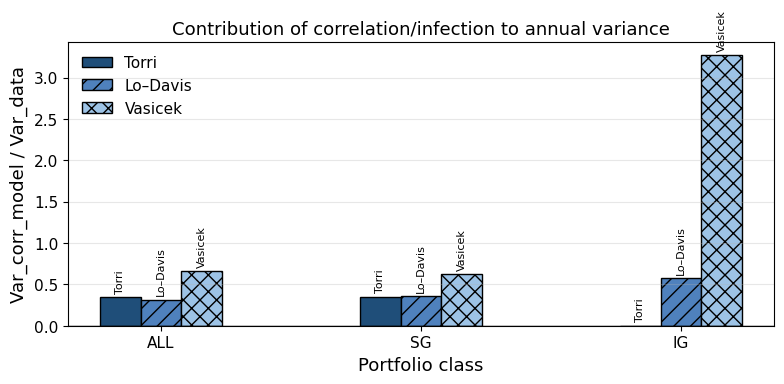

In [15]:
mpl.rcParams["pdf.fonttype"] = 42

# ---------- palette ----------
bar_colors = ["#1f4e79", "#4f81bd", "#9dc3e6"]
hatches = ["", "//", "xx"]

models = ["Torri", "Lo–Davis", "Vasicek"]
classes = ["ALL", "SG", "IG"]

# =========================
# Data preparation
# =========================
pivotB = (
    out_var3
    .pivot(index="class", columns="model", values="Explained_corr_over_VarData")
    .reindex(index=classes, columns=models)
)

# =========================
# Manual bar plot
# =========================
fig, ax = plt.subplots(figsize=(8,4))

x = np.arange(len(classes)) * 1.6   # wider spacing between groups
width = 0.25                        # bar width

for i, model in enumerate(models):
    offsets = x + (i - 1) * width   # left / center / right placement
    
    bars = ax.bar(
        offsets,
        pivotB[model],
        width=width,
        color=bar_colors[i],
        edgecolor="black",
        hatch=hatches[i],
        label=model
    )
    
    for bar in bars:
        h = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width()/2,
            h + 0.05,
            model,
            ha="center",
            va="bottom",
            fontsize=8,
            rotation=90
        )

# =========================
# Axes
# =========================
ax.set_xticks(x)
ax.set_xticklabels(classes)

ax.axhline(0, linewidth=1, color="black")
ax.set_ylabel("Var_corr_model / Var_data")
ax.set_xlabel("Portfolio class")
ax.set_title("Contribution of correlation/infection to annual variance")

ax.grid(axis="y", alpha=0.3)

# Remove the legend if not needed
ax.legend(frameon=False)

plt.tight_layout()
plt.savefig("figure3_variance_decomposition.pdf", bbox_inches="tight")
plt.show()

In [16]:
# ==========================================
# Hierarchical Lo–Davis model (MLE)
#   probit(p_t) = y_t ~ N(mu, sigma^2)
#   L_t | n_t, p_t, q ~ LD(n_t, p_t, q)
#
# Existing functions reused:
#   - log_pmf_LD_1pt(n, h, p, q)
#   - logsumexp_vec(logw)
#   - df
# ==========================================

# ---------- utilities ----------
def log_pmf_hier_LD_1pt(n, h, mu, sigma, q, gh_x, gh_w):
    """
    log P(L=h | n, mu, sigma, q)
      = log ∫ P_LD(L=h | n, p=Phi(y), q) * N(y | mu, sigma^2) dy
      = log [ (1/sqrt(pi)) sum_j w_j * P_LD(h | n, Phi(mu + sqrt(2)sigma x_j), q) ]
    """
    if not (0 <= h <= n):
        return -np.inf
    if sigma <= 0:
        return -np.inf
    if not (0.0 < q < 1.0):
        return -np.inf

    # GH approximation
    log_terms = np.full(len(gh_w), -np.inf, dtype=float)

    for j, (xj, wj) in enumerate(zip(gh_x, gh_w)):
        y = mu + math.sqrt(2.0) * sigma * float(xj)
        p = float(norm.cdf(y))

        # protect against exact 0/1
        p = float(np.clip(p, 1e-15, 1.0 - 1e-15))

        lp = log_pmf_LD_1pt(int(n), int(h), p, float(q))
        if np.isfinite(lp):
            log_terms[j] = math.log(float(wj)) + lp

    out = logsumexp_vec(log_terms) - 0.5 * math.log(math.pi)
    return float(out)

# ---------- negative log-likelihood ----------
def neg_ll_hier_LD(theta, n_arr, h_arr, c_arr, gh_x, gh_w):
    """
    theta = (mu_raw, sigma_raw, q_raw)
      mu    = mu_raw
      sigma = softplus(sigma_raw)
      q     = sigmoid(q_raw)
    """
    mu = float(theta[0])
    sigma = float(softplus(theta[1]))
    q = float(sigmoid(theta[2]))

    ll = 0.0
    for n, h, c in zip(n_arr, h_arr, c_arr):
        lp = log_pmf_hier_LD_1pt(int(n), int(h), mu, sigma, q, gh_x, gh_w)
        if not np.isfinite(lp):
            return 1e100
        ll += int(c) * lp

    return float(-ll)

# ---------- fit ----------
def fit_one_hier_LD(
    series_n,
    series_h,
    GH_N=20,
    x0=None,
    maxiter=5000,
    method="Nelder-Mead",
):
    """
    Hierarchical LD MLE.

    Parameters
    ----------
    series_n, series_h : pandas Series
        Observed n_t and L_t
    GH_N : int
        Number of Gauss-Hermite nodes
    x0 : array-like or None
        Initial values for unconstrained params (mu_raw, sigma_raw, q_raw)
    """
    n_arr, h_arr, c_arr = make_grouped_nh(series_n, series_h)
    gh_x, gh_w = hermgauss(GH_N)

    # crude initial values from overall default rate
    m_hat = float(series_h.sum() / series_n.sum())
    mu0 = float(norm.ppf(np.clip(m_hat, 1e-6, 1.0 - 1e-6)))
    sigma0 = 0.5
    q0 = 0.01

    if x0 is None:
        x0 = np.array([
            mu0,
            inv_softplus(sigma0),
            math.log(q0 / (1.0 - q0)),
        ], dtype=float)

    res = minimize(
        neg_ll_hier_LD,
        x0=x0,
        args=(n_arr, h_arr, c_arr, gh_x, gh_w),
        method=method,
        options={"maxiter": maxiter},
    )

    mu_hat = float(res.x[0])
    sigma_hat = float(softplus(res.x[1]))
    q_hat = float(sigmoid(res.x[2]))

    return {
        "mu": mu_hat,
        "sigma": sigma_hat,
        "q": q_hat,
        "nll": float(res.fun),
        "success": bool(res.success),
        "nit": int(res.nit),
        "message": str(res.message),
        "GH_N": int(GH_N),
        "m_hat_init": m_hat,
    }

# ---------- optional: posterior summaries of p_t ----------
def posterior_mean_pt_hier_LD(n, h, mu, sigma, q, gh_x, gh_w):
    """
    E[p_t | L_t=h, n_t=n, mu, sigma, q] by GH approximation
    """
    logw = np.full(len(gh_w), -np.inf, dtype=float)
    pvals = np.zeros(len(gh_w), dtype=float)

    for j, (xj, wj) in enumerate(zip(gh_x, gh_w)):
        y = mu + math.sqrt(2.0) * sigma * float(xj)
        p = float(norm.cdf(y))
        p = float(np.clip(p, 1e-15, 1.0 - 1e-15))
        lp = log_pmf_LD_1pt(int(n), int(h), p, float(q))
        if np.isfinite(lp):
            logw[j] = math.log(float(wj)) + lp
            pvals[j] = p

    z = logsumexp_vec(logw)
    if not np.isfinite(z):
        return np.nan

    w_norm = np.exp(logw - z)
    return float(np.sum(w_norm * pvals))

def add_posterior_mean_pt_column(df_in, key, fit_out):
    """
    Add posterior mean p_t column for one class.
    """
    gh_x, gh_w = hermgauss(int(fit_out["GH_N"]))
    mu = float(fit_out["mu"])
    sigma = float(fit_out["sigma"])
    q = float(fit_out["q"])

    out = df_in.copy()
    p_post = []
    for n, h in zip(out[key].astype(int), out["D_" + key].astype(int)):
        p_post.append(posterior_mean_pt_hier_LD(int(n), int(h), mu, sigma, q, gh_x, gh_w))
    out["p_post_mean_" + key] = p_post
    return out

# ==========================================
# Run fits
# ==========================================

out_all_hier_ld = fit_one_hier_LD(df["ALL"], df["D_ALL"], GH_N=100, maxiter=6000)
out_sg_hier_ld  = fit_one_hier_LD(df["SG"],  df["D_SG"],  GH_N=100, maxiter=6000)
out_ig_hier_ld  = fit_one_hier_LD(df["IG"],  df["D_IG"],  GH_N=100, maxiter=6000)

print("ALL hierarchical LD fit:", out_all_hier_ld)
print("SG  hierarchical LD fit:", out_sg_hier_ld)
print("IG  hierarchical LD fit:", out_ig_hier_ld)

ALL hierarchical LD fit: {'mu': -2.8038566421539377, 'sigma': 0.25540832289405474, 'q': 0.0010775111857981112, 'nll': 413.8253066284348, 'success': True, 'nit': 100, 'message': 'Optimization terminated successfully.', 'GH_N': 100, 'm_hat_init': 0.015664420349169685}
SG  hierarchical LD fit: {'mu': -2.444158019386139, 'sigma': 0.27498674086977, 'q': 0.002393652078255974, 'nll': 401.342170645119, 'success': True, 'nit': 84, 'message': 'Optimization terminated successfully.', 'GH_N': 100, 'm_hat_init': 0.03783505253012968}
IG  hierarchical LD fit: {'mu': -3.340888635828734, 'sigma': 0.4271940090769476, 'q': 0.0002790161814737799, 'nll': 180.78127375971007, 'success': True, 'nit': 82, 'message': 'Optimization terminated successfully.', 'GH_N': 100, 'm_hat_init': 0.0013886158081006686}


## Variance decomposition
Decompose empirical variance into model-implied components.

In [17]:
# ============================================================
# Hierarchical Lo–Davis: variance decomposition at fixed nbar
#
# Goal:
#   Var(L) = E[ Var(L | p_t) ] + Var( E[L | p_t] )
#          =  E[ nbar * m_t (1-m_t) ]                  [iid]
#           + E[ nbar (nbar-1) * (q_t - m_t^2) ]      [infection]
#           + Var( nbar * m_t )                       [p_t fluctuation]
#
# where for LD at fixed p:
#   m_t = m(nbar, p_t, q)
#   q_t = q_pair(nbar, p_t, q)
#
# Reuse:
#   - NBAR
#   - ld_m_q_for_n(n, p, q_param)
#   - fit results out_all_hier_ld, out_sg_hier_ld, out_ig_hier_ld
# ============================================================

# ---------- hierarchical LD fits dict ----------
fits_hier_ld = {
    "ALL": {
        "mu": float(out_all_hier_ld["mu"]),
        "sigma": float(out_all_hier_ld["sigma"]),
        "q": float(out_all_hier_ld["q"]),
        "GH_N": int(out_all_hier_ld["GH_N"]),
    },
    "SG": {
        "mu": float(out_sg_hier_ld["mu"]),
        "sigma": float(out_sg_hier_ld["sigma"]),
        "q": float(out_sg_hier_ld["q"]),
        "GH_N": int(out_sg_hier_ld["GH_N"]),
    },
    "IG": {
        "mu": float(out_ig_hier_ld["mu"]),
        "sigma": float(out_ig_hier_ld["sigma"]),
        "q": float(out_ig_hier_ld["q"]),
        "GH_N": int(out_ig_hier_ld["GH_N"]),
    },
}

# ---------- helpers ----------
def variance_decomp_hier_ld_fixed_nbar(
    df,
    NBAR,
    fits_hier_ld,
    keys=("ALL", "SG", "IG"),
):
    rows = []

    for key in keys:
        nbar = int(NBAR[key])
        n_vals, L_vals = _clean_nL(df, key)
        L_scaled = scaled_counts(n_vals, L_vals, nbar)

        # data-side quantities under the same fixed-nbar scaling
        var_data_scaled = float(np.var(L_scaled, ddof=1)) if len(L_scaled) >= 2 else np.nan
        m_hat_data = float(np.sum(L_vals) / np.sum(n_vals))
        var_iid_data_scaled = float(nbar * m_hat_data * (1.0 - m_hat_data))
        var_corr_data_scaled = var_data_scaled - var_iid_data_scaled if np.isfinite(var_data_scaled) else np.nan

        # fitted hyperparameters
        mu = float(fits_hier_ld[key]["mu"])
        sigma = float(fits_hier_ld[key]["sigma"])
        q_param = float(fits_hier_ld[key]["q"])
        GH_N = int(fits_hier_ld[key]["GH_N"])

        # GH quadrature for p_t = Phi(y_t), y_t ~ N(mu, sigma^2)
        y_nodes, w_nodes = gh_normal_weights(mu, sigma, GH_N)
        p_nodes = norm.cdf(y_nodes)
        p_nodes = np.clip(p_nodes, 1e-15, 1.0 - 1e-15)

        # model-implied m_t, q_t at fixed nbar for each quadrature node
        m_nodes = np.empty_like(p_nodes, dtype=float)
        q_nodes = np.empty_like(p_nodes, dtype=float)

        for j, p_t in enumerate(p_nodes):
            m_t, q_t = ld_m_q_for_n(nbar, float(p_t), q_param)
            m_nodes[j] = m_t
            q_nodes[j] = q_t

        # decomposition
        var_iid_model = float(np.sum(w_nodes * (nbar * m_nodes * (1.0 - m_nodes))))
        var_infect_model = float(np.sum(w_nodes * (nbar * (nbar - 1) * (q_nodes - m_nodes**2))))
        var_pt_model = float(np.sum(w_nodes * (nbar * m_nodes)**2) - (np.sum(w_nodes * (nbar * m_nodes)))**2)

        var_model_total = var_iid_model + var_infect_model + var_pt_model

        # additional summaries
        m_bar = float(np.sum(w_nodes * m_nodes))
        q_bar = float(np.sum(w_nodes * q_nodes))
        rho_bar = (q_bar - m_bar*m_bar) / (m_bar * (1.0 - m_bar)) if m_bar * (1.0 - m_bar) > 1e-15 else np.nan

        rows.append({
            "class": key,
            "nbar": nbar,
            "mu": mu,
            "sigma": sigma,
            "q_param": q_param,
            "GH_N": GH_N,
            "Var_data_scaled": var_data_scaled,
            "m_hat_data": m_hat_data,
            "Var_iid_data_scaled": var_iid_data_scaled,
            "Var_corr_data_scaled": var_corr_data_scaled,
            "m_bar_model": m_bar,
            "q_bar_model": q_bar,
            "rho_bar_model": rho_bar,
            "Var_iid_model": var_iid_model,
            "Var_infect_model": var_infect_model,
            "Var_pt_model": var_pt_model,
            "Var_model_total": var_model_total,
            "Share_iid_within_model": (var_iid_model / var_model_total) if var_model_total > 0 else np.nan,
            "Share_infect_within_model": (var_infect_model / var_model_total) if var_model_total > 0 else np.nan,
            "Share_pt_within_model": (var_pt_model / var_model_total) if var_model_total > 0 else np.nan,
            "Infect_over_VarData": (var_infect_model / var_data_scaled) if (np.isfinite(var_data_scaled) and var_data_scaled > 0) else np.nan,
            "Pt_over_VarData": (var_pt_model / var_data_scaled) if (np.isfinite(var_data_scaled) and var_data_scaled > 0) else np.nan,
            "Iid_over_VarData": (var_iid_model / var_data_scaled) if (np.isfinite(var_data_scaled) and var_data_scaled > 0) else np.nan,
        })

    return pd.DataFrame(rows)

# ---------- run ----------
out_var_hier_ld = variance_decomp_hier_ld_fixed_nbar(
    df=df,
    NBAR=NBAR,
    fits_hier_ld=fits_hier_ld,
    keys=("ALL", "SG", "IG"),
)

pd.set_option("display.float_format", lambda x: f"{x:.6g}")
display(out_var_hier_ld)

,class,nbar,mu,sigma,q_param,GH_N,Var_data_scaled,m_hat_data,Var_iid_data_scaled,Var_corr_data_scaled,...,Var_iid_model,Var_infect_model,Var_pt_model,Var_model_total,Share_iid_within_model,Share_infect_within_model,Share_pt_within_model,Infect_over_VarData,Pt_over_VarData,Iid_over_VarData
0,ALL,2573,-2.80386,0.255408,0.00107751,100,1190.68,0.0156644,39.6732,1151.01,...,31.0289,107.225,684.346,822.6,0.0377205,0.130349,0.83193,0.0900536,0.574752,0.0260597
1,SG,1008,-2.44416,0.274987,0.00239365,100,863.478,0.0378351,36.6948,826.783,...,29.4668,88.6966,559.274,677.437,0.0434975,0.13093,0.825573,0.10272,0.647699,0.0341257
2,IG,1565,-3.34089,0.427194,0.000279016,100,17.2472,0.00138862,2.17017,15.077,...,2.36667,1.74113,20.2719,24.3797,0.0970754,0.0714169,0.831508,0.100951,1.17538,0.137221


In [18]:
# ==========================================
# Hierarchical Torri model (MLE)
#   probit(p_t) = y_t ~ N(mu, sigma^2)
#   L_t | n_t, p_t, u, v ~ Torri(n_t, p_t, u, v)
#
# Existing functions reused:
#   - log_pmf_Torri(n, h, p, u, v)
#   - logsumexp_vec(logw)
#   - df
# ==========================================

# ---------- utilities ----------
def log_pmf_hier_Torri_1pt(n, h, mu, sigma, u, v, gh_x, gh_w):
    """
    log P(L=h | n, mu, sigma, u, v)
      = log ∫ P_Torri(L=h | n, p=Phi(y), u, v) * N(y | mu, sigma^2) dy
      = log [ (1/sqrt(pi)) sum_j w_j * P_Torri(h | n, Phi(mu + sqrt(2)sigma x_j), u, v) ]
    """
    if not (0 <= h <= n):
        return -np.inf
    if sigma <= 0:
        return -np.inf
    if not (0.0 <= u <= 1.0 and 0.0 <= v <= 1.0):
        return -np.inf

    log_terms = np.full(len(gh_w), -np.inf, dtype=float)

    for j, (xj, wj) in enumerate(zip(gh_x, gh_w)):
        y = mu + math.sqrt(2.0) * sigma * float(xj)
        p = float(norm.cdf(y))
        p = float(np.clip(p, 1e-15, 1.0 - 1e-15))

        lp = log_pmf_Torri(int(n), int(h), p, float(u), float(v))
        if np.isfinite(lp):
            log_terms[j] = math.log(float(wj)) + lp

    out = logsumexp_vec(log_terms) - 0.5 * math.log(math.pi)
    return float(out)

# ---------- negative log-likelihood ----------
def neg_ll_hier_Torri(theta, n_arr, h_arr, c_arr, gh_x, gh_w):
    """
    theta = (mu_raw, sigma_raw, u_raw, v_raw)
      mu    = mu_raw
      sigma = softplus(sigma_raw)
      u     = sigmoid(u_raw)
      v     = sigmoid(v_raw)
    """
    mu = float(theta[0])
    sigma = float(softplus(theta[1]))
    u = float(sigmoid(theta[2]))
    v = float(sigmoid(theta[3]))

    ll = 0.0
    for n, h, c in zip(n_arr, h_arr, c_arr):
        lp = log_pmf_hier_Torri_1pt(int(n), int(h), mu, sigma, u, v, gh_x, gh_w)
        if not np.isfinite(lp):
            return 1e100
        ll += int(c) * lp

    return float(-ll)

# ---------- fit ----------
def fit_one_hier_Torri(
    series_n,
    series_h,
    GH_N=20,
    x0=None,
    maxiter=7000,
    method="Nelder-Mead",
):
    """
    Hierarchical Torri MLE.
    """
    n_arr, h_arr, c_arr = make_grouped_nh(series_n, series_h)
    gh_x, gh_w = hermgauss(GH_N)

    # crude initial values
    m_hat = float(series_h.sum() / series_n.sum())
    mu0 = float(norm.ppf(np.clip(m_hat, 1e-6, 1.0 - 1e-6)))
    sigma0 = 0.5
    u0 = 0.9
    v0 = 0.01

    if x0 is None:
        x0 = np.array([
            mu0,
            inv_softplus(sigma0),
            math.log(u0 / (1.0 - u0)),
            math.log(v0 / (1.0 - v0)),
        ], dtype=float)

    res = minimize(
        neg_ll_hier_Torri,
        x0=x0,
        args=(n_arr, h_arr, c_arr, gh_x, gh_w),
        method=method,
        options={"maxiter": maxiter},
    )

    mu_hat = float(res.x[0])
    sigma_hat = float(softplus(res.x[1]))
    u_hat = float(sigmoid(res.x[2]))
    v_hat = float(sigmoid(res.x[3]))

    return {
        "mu": mu_hat,
        "sigma": sigma_hat,
        "u": u_hat,
        "v": v_hat,
        "nll": float(res.fun),
        "success": bool(res.success),
        "nit": int(res.nit),
        "message": str(res.message),
        "GH_N": int(GH_N),
        "m_hat_init": m_hat,
    }

# ---------- optional: posterior mean of p_t ----------
def posterior_mean_pt_hier_Torri(n, h, mu, sigma, u, v, gh_x, gh_w):
    logw = np.full(len(gh_w), -np.inf, dtype=float)
    pvals = np.zeros(len(gh_w), dtype=float)

    for j, (xj, wj) in enumerate(zip(gh_x, gh_w)):
        y = mu + math.sqrt(2.0) * sigma * float(xj)
        p = float(norm.cdf(y))
        p = float(np.clip(p, 1e-15, 1.0 - 1e-15))
        lp = log_pmf_Torri(int(n), int(h), p, float(u), float(v))
        if np.isfinite(lp):
            logw[j] = math.log(float(wj)) + lp
            pvals[j] = p

    z = logsumexp_vec(logw)
    if not np.isfinite(z):
        return np.nan

    w_norm = np.exp(logw - z)
    return float(np.sum(w_norm * pvals))

def add_posterior_mean_pt_column_torri(df_in, key, fit_out):
    gh_x, gh_w = hermgauss(int(fit_out["GH_N"]))
    mu = float(fit_out["mu"])
    sigma = float(fit_out["sigma"])
    u = float(fit_out["u"])
    v = float(fit_out["v"])

    out = df_in.copy()
    p_post = []
    for n, h in zip(out[key].astype(int), out["D_" + key].astype(int)):
        p_post.append(posterior_mean_pt_hier_Torri(int(n), int(h), mu, sigma, u, v, gh_x, gh_w))
    out["p_post_mean_" + key] = p_post
    return out

# ==========================================
# Run fits
# ==========================================

out_all_hier_torri = fit_one_hier_Torri(df["ALL"], df["D_ALL"], GH_N=100, maxiter=8000)
out_sg_hier_torri  = fit_one_hier_Torri(df["SG"],  df["D_SG"],  GH_N=100, maxiter=8000)
out_ig_hier_torri  = fit_one_hier_Torri(df["IG"],  df["D_IG"],  GH_N=100, maxiter=8000)

print("ALL hierarchical Torri fit:", out_all_hier_torri)
print("SG  hierarchical Torri fit:", out_sg_hier_torri)
print("IG  hierarchical Torri fit:", out_ig_hier_torri)

ALL hierarchical Torri fit: {'mu': -2.475993179307539, 'sigma': 0.457635530794807, 'u': 0.9090753133654194, 'v': 2.116750312951464e-15, 'nll': 432.71291617850625, 'success': True, 'nit': 261, 'message': 'Optimization terminated successfully.', 'GH_N': 100, 'm_hat_init': 0.015664420349169685}
SG  hierarchical Torri fit: {'mu': -2.1305322808405274, 'sigma': 0.5161613511205921, 'u': 0.9881454579765498, 'v': 0.17167136412187906, 'nll': 409.2666282625759, 'success': True, 'nit': 271, 'message': 'Optimization terminated successfully.', 'GH_N': 100, 'm_hat_init': 0.03783505253012968}
IG  hierarchical Torri fit: {'mu': -3.2928210018296946, 'sigma': 0.5000006126431742, 'u': 9.30643862521654e-11, 'v': 5.8622669111030944e-15, 'nll': 182.3816860461229, 'success': True, 'nit': 227, 'message': 'Optimization terminated successfully.', 'GH_N': 100, 'm_hat_init': 0.0013886158081006686}


In [19]:
# ============================================================
# Hierarchical Torri: variance decomposition at fixed nbar
#
# Goal:
#   Var(L) = E[ Var(L | p_t) ] + Var( E[L | p_t] )
#          =  E[ nbar * m_t (1-m_t) ]                  [iid]
#           + E[ nbar (nbar-1) * (q_t - m_t^2) ]      [infection]
#           + Var( nbar * m_t )                       [p_t fluctuation]
#
# where for Torri at fixed p:
#   m_t = m(nbar, p_t, u, v)
#   q_t = q_pair(nbar, p_t, u, v)
#
# Reuse:
#   - NBAR
#   - scaled_counts(...)
#   - out_all_hier_torri, out_sg_hier_torri, out_ig_hier_torri
# ============================================================

# ---------- hierarchical Torri fits dict ----------
fits_hier_torri = {
    "ALL": {
        "mu": float(out_all_hier_torri["mu"]),
        "sigma": float(out_all_hier_torri["sigma"]),
        "u": float(out_all_hier_torri["u"]),
        "v": float(out_all_hier_torri["v"]),
        "GH_N": int(out_all_hier_torri["GH_N"]),
    },
    "SG": {
        "mu": float(out_sg_hier_torri["mu"]),
        "sigma": float(out_sg_hier_torri["sigma"]),
        "u": float(out_sg_hier_torri["u"]),
        "v": float(out_sg_hier_torri["v"]),
        "GH_N": int(out_sg_hier_torri["GH_N"]),
    },
    "IG": {
        "mu": float(out_ig_hier_torri["mu"]),
        "sigma": float(out_ig_hier_torri["sigma"]),
        "u": float(out_ig_hier_torri["u"]),
        "v": float(out_ig_hier_torri["v"]),
        "GH_N": int(out_ig_hier_torri["GH_N"]),
    },
}

# ---------- helpers ----------
def variance_decomp_hier_torri_fixed_nbar(
    df,
    NBAR,
    fits_hier_torri,
    keys=("ALL", "SG", "IG"),
):
    rows = []

    for key in keys:
        nbar = int(NBAR[key])

        # data-side quantities under the same fixed-nbar scaling
        n_vals, L_vals = _clean_nL(df, key)
        L_scaled = scaled_counts(n_vals, L_vals, nbar)
        var_data_scaled = float(np.var(L_scaled, ddof=1)) if len(L_scaled) >= 2 else np.nan
        m_hat_data = float(np.sum(L_vals) / np.sum(n_vals))
        var_iid_data_scaled = float(nbar * m_hat_data * (1.0 - m_hat_data))
        var_corr_data_scaled = var_data_scaled - var_iid_data_scaled if np.isfinite(var_data_scaled) else np.nan

        # fitted hyperparameters
        mu = float(fits_hier_torri[key]["mu"])
        sigma = float(fits_hier_torri[key]["sigma"])
        u = float(fits_hier_torri[key]["u"])
        v = float(fits_hier_torri[key]["v"])
        GH_N = int(fits_hier_torri[key]["GH_N"])

        # GH quadrature for p_t = Phi(y_t), y_t ~ N(mu, sigma^2)
        y_nodes, w_nodes = gh_normal_weights(mu, sigma, GH_N)
        p_nodes = norm.cdf(y_nodes)
        p_nodes = np.clip(p_nodes, 1e-15, 1.0 - 1e-15)

        # model-implied m_t, q_t at fixed nbar for each quadrature node
        m_nodes = np.empty_like(p_nodes, dtype=float)
        q_nodes = np.empty_like(p_nodes, dtype=float)

        for j, p_t in enumerate(p_nodes):
            m_t, q_t = torri_m_q_for_n(nbar, float(p_t), u, v)
            m_nodes[j] = m_t
            q_nodes[j] = q_t

        # decomposition
        var_iid_model = float(np.sum(w_nodes * (nbar * m_nodes * (1.0 - m_nodes))))
        var_infect_model = float(np.sum(w_nodes * (nbar * (nbar - 1) * (q_nodes - m_nodes**2))))
        var_pt_model = float(np.sum(w_nodes * (nbar * m_nodes)**2) - (np.sum(w_nodes * (nbar * m_nodes)))**2)

        var_model_total = var_iid_model + var_infect_model + var_pt_model

        # additional summaries
        m_bar = float(np.sum(w_nodes * m_nodes))
        q_bar = float(np.sum(w_nodes * q_nodes))
        rho_bar = aggregate_m_q_to_rho(m_bar, q_bar)

        rows.append({
            "class": key,
            "nbar": nbar,
            "mu": mu,
            "sigma": sigma,
            "u": u,
            "v": v,
            "GH_N": GH_N,
            "Var_data_scaled": var_data_scaled,
            "m_hat_data": m_hat_data,
            "Var_iid_data_scaled": var_iid_data_scaled,
            "Var_corr_data_scaled": var_corr_data_scaled,
            "m_bar_model": m_bar,
            "q_bar_model": q_bar,
            "rho_bar_model": rho_bar,
            "Var_iid_model": var_iid_model,
            "Var_infect_model": var_infect_model,
            "Var_pt_model": var_pt_model,
            "Var_model_total": var_model_total,
            "Share_iid_within_model": (var_iid_model / var_model_total) if var_model_total > 0 else np.nan,
            "Share_infect_within_model": (var_infect_model / var_model_total) if var_model_total > 0 else np.nan,
            "Share_pt_within_model": (var_pt_model / var_model_total) if var_model_total > 0 else np.nan,
            "Iid_over_VarData": (var_iid_model / var_data_scaled) if (np.isfinite(var_data_scaled) and var_data_scaled > 0) else np.nan,
            "Infect_over_VarData": (var_infect_model / var_data_scaled) if (np.isfinite(var_data_scaled) and var_data_scaled > 0) else np.nan,
            "Pt_over_VarData": (var_pt_model / var_data_scaled) if (np.isfinite(var_data_scaled) and var_data_scaled > 0) else np.nan,
        })

    return pd.DataFrame(rows)

# ---------- run ----------
out_var_hier_torri = variance_decomp_hier_torri_fixed_nbar(
    df=df,
    NBAR=NBAR,
    fits_hier_torri=fits_hier_torri,
    keys=("ALL", "SG", "IG"),
)

## Variance decomposition table
Display the variance-decomposition comparison across models and classes.

In [20]:
# ============================================================
# Final summary figure:
# Hierarchical Lo–Davis vs Hierarchical Torri
# Variance components relative to empirical annual variance
#
# Reuse:
#   - out_var_hier_ld
#   - out_var_hier_torri
# ============================================================

# ------------------------------------------------------------
# 1. Build tidy comparison table
# ------------------------------------------------------------
df_cmp_decomp = build_compare_decomp_table(out_var_hier_ld, out_var_hier_torri)
display(df_cmp_decomp)

# ------------------------------------------------------------
# 2. Prepare plotting data
# ------------------------------------------------------------
classes = ["ALL", "SG", "IG"]
models = ["Lo–Davis", "Torri"]

labels = []
iid_vals = []
inf_vals = []
pt_vals = []

for c in classes:
    for m in models:
        sub = df_cmp_decomp[(df_cmp_decomp["class"] == c) & (df_cmp_decomp["model"] == m)]
        labels.append(f"{c}\n{'LD' if m == 'Lo–Davis' else 'Torri'}")
        iid_vals.append(sub["Iid_over_VarData"].values[0])
        inf_vals.append(sub["Infect_over_VarData"].values[0])
        pt_vals.append(sub["Pt_over_VarData"].values[0])

iid_vals = np.array(iid_vals, dtype=float)
inf_vals = np.array(inf_vals, dtype=float)
pt_vals  = np.array(pt_vals, dtype=float)

x = np.arange(len(labels))
width = 0.72

# colors
c_iid = "#4C78A8"
c_inf = "#F58518"
c_pt  = "#54A24B"

,class,Share_iid_within_model,Share_infect_within_model,Share_pt_within_model,Iid_over_VarData,Infect_over_VarData,Pt_over_VarData,model
0,ALL,0.0377205,0.130349,0.83193,0.0260597,0.0900536,0.574752,Lo–Davis
1,ALL,0.0169905,9.53868e-13,0.98301,0.025426,1.42745e-12,1.47106,Torri
2,IG,0.0970754,0.0714169,0.831508,0.137221,0.100951,1.17538,Lo–Davis
3,IG,0.0735969,3.95358e-10,0.926403,0.145032,7.79101e-10,1.82559,Torri
4,SG,0.0434975,0.13093,0.825573,0.0341257,0.10272,0.647699,Lo–Davis
5,SG,0.0239967,0.0109111,0.965092,0.0414287,0.0188373,1.66617,Torri


## Figure generation
Generate the comparison figures used in the analysis.

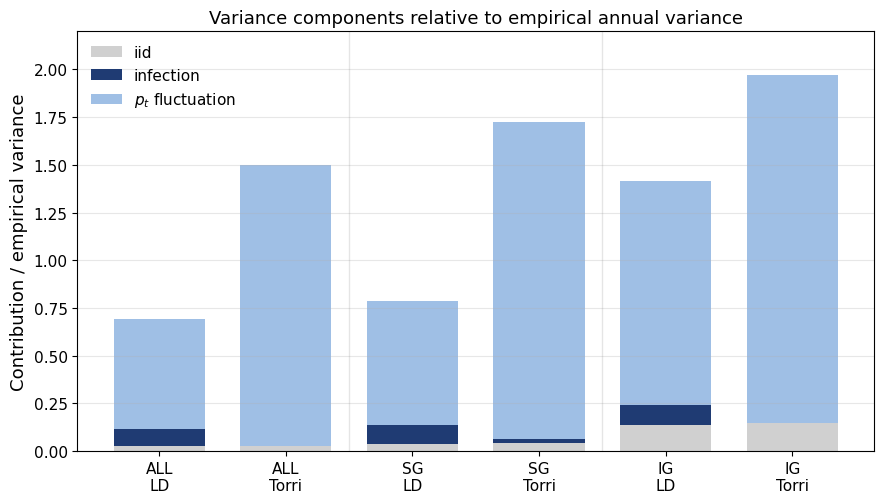

In [21]:
# ============================================================
# Final summary figure (paper style: blue + grayscale)
# Hierarchical Lo–Davis vs Hierarchical Torri
# ============================================================

# ------------------------------------------------------------
# 1. Build tidy table
# ------------------------------------------------------------
df_cmp_decomp = build_compare_decomp_table(out_var_hier_ld, out_var_hier_torri)

# ------------------------------------------------------------
# 2. Prepare plotting data
# ------------------------------------------------------------
classes = ["ALL", "SG", "IG"]
models = ["Lo–Davis", "Torri"]

labels = []
iid_vals = []
inf_vals = []
pt_vals = []

for c in classes:
    for m in models:
        sub = df_cmp_decomp[(df_cmp_decomp["class"] == c) & (df_cmp_decomp["model"] == m)]
        labels.append(f"{c}\n{'LD' if m == 'Lo–Davis' else 'Torri'}")
        iid_vals.append(sub["Iid_over_VarData"].values[0])
        inf_vals.append(sub["Infect_over_VarData"].values[0])
        pt_vals.append(sub["Pt_over_VarData"].values[0])

iid_vals = np.array(iid_vals)
inf_vals = np.array(inf_vals)
pt_vals  = np.array(pt_vals)

x = np.arange(len(labels))
width = 0.72

# ------------------------------------------------------------
# 3. Paper-style colors (blue + grayscale)
# ------------------------------------------------------------

c_iid = "#D0D0D0"   # light gray
c_pt  = "#9FBFE5"   # light blue
c_inf = "#1F3B73"   # dark blue

# ------------------------------------------------------------
# 4. Plot
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(9, 5.2))

ax.bar(x, iid_vals, width=width, color=c_iid, label="iid")
ax.bar(x, inf_vals, width=width, bottom=iid_vals, color=c_inf, label="infection")
ax.bar(x, pt_vals,  width=width, bottom=iid_vals + inf_vals, color=c_pt, label="$p_t$ fluctuation")

# group separators
for pos in [1.5, 3.5]:
    ax.axvline(pos, color="gray", alpha=0.2, linewidth=1)

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("Contribution / empirical variance")
ax.set_title("Variance components relative to empirical annual variance")
ax.set_ylim(0, 2.2)
ax.grid(axis="y", alpha=0.3)

ax.legend(frameon=False)

plt.tight_layout()
plt.savefig("figure4_variance_decomp_hier_compare.pdf", bbox_inches="tight")
plt.show()

## Variance decomposition table
Display the variance-decomposition comparison across models and classes.

In [22]:
display(df_cmp_decomp)

,class,Share_iid_within_model,Share_infect_within_model,Share_pt_within_model,Iid_over_VarData,Infect_over_VarData,Pt_over_VarData,model
0,ALL,0.0377205,0.130349,0.83193,0.0260597,0.0900536,0.574752,Lo–Davis
1,ALL,0.0169905,9.53868e-13,0.98301,0.025426,1.42745e-12,1.47106,Torri
2,IG,0.0970754,0.0714169,0.831508,0.137221,0.100951,1.17538,Lo–Davis
3,IG,0.0735969,3.95358e-10,0.926403,0.145032,7.79101e-10,1.82559,Torri
4,SG,0.0434975,0.13093,0.825573,0.0341257,0.10272,0.647699,Lo–Davis
5,SG,0.0239967,0.0109111,0.965092,0.0414287,0.0188373,1.66617,Torri


## Tail-risk diagnostics
Compute tail-focused summaries such as VaR, ES, and survival-based comparisons.

In [23]:
# ============================================================
# Tail comparison at fixed nbar:
#   Data(scaled) vs Vasicek vs Hierarchical LD vs Hierarchical Torri
#
# Reuse:
#   - NBAR
#   - scaled_counts(...)
#   - empirical_pmf_from_counts(...)
#   - tail_metrics_from_pmf(...)
#   - log_pmf_Vas_1pt(...)
#   - log_pmf_LD_1pt(...)
#   - log_pmf_Torri(...)
#   - normalize_logpmf(...)
#   - out_all_vas, out_sg_vas, out_ig_vas
#   - out_all_hier_ld, out_sg_hier_ld, out_ig_hier_ld
#   - out_all_hier_torri, out_sg_hier_torri, out_ig_hier_torri
# ============================================================

# ---------- fit dicts ----------
fits_vas = {
    "ALL": {"p": float(out_all_vas["p"]), "rho_A": float(out_all_vas["rho_A"])},
    "SG":  {"p": float(out_sg_vas["p"]),  "rho_A": float(out_sg_vas["rho_A"])},
    "IG":  {"p": float(out_ig_vas["p"]),  "rho_A": float(out_ig_vas["rho_A"])},
}

fits_hier_ld = {
    "ALL": {"mu": float(out_all_hier_ld["mu"]), "sigma": float(out_all_hier_ld["sigma"]), "q": float(out_all_hier_ld["q"]), "GH_N": int(out_all_hier_ld["GH_N"])},
    "SG":  {"mu": float(out_sg_hier_ld["mu"]),  "sigma": float(out_sg_hier_ld["sigma"]),  "q": float(out_sg_hier_ld["q"]),  "GH_N": int(out_sg_hier_ld["GH_N"])},
    "IG":  {"mu": float(out_ig_hier_ld["mu"]),  "sigma": float(out_ig_hier_ld["sigma"]),  "q": float(out_ig_hier_ld["q"]),  "GH_N": int(out_ig_hier_ld["GH_N"])},
}

fits_hier_torri = {
    "ALL": {"mu": float(out_all_hier_torri["mu"]), "sigma": float(out_all_hier_torri["sigma"]), "u": float(out_all_hier_torri["u"]), "v": float(out_all_hier_torri["v"]), "GH_N": int(out_all_hier_torri["GH_N"])},
    "SG":  {"mu": float(out_sg_hier_torri["mu"]),  "sigma": float(out_sg_hier_torri["sigma"]),  "u": float(out_sg_hier_torri["u"]),  "v": float(out_sg_hier_torri["v"]),  "GH_N": int(out_sg_hier_torri["GH_N"])},
    "IG":  {"mu": float(out_ig_hier_torri["mu"]),  "sigma": float(out_ig_hier_torri["sigma"]),  "u": float(out_ig_hier_torri["u"]),  "v": float(out_ig_hier_torri["v"]),  "GH_N": int(out_ig_hier_torri["GH_N"])},
}

# ---------- helpers ----------
def pmf_vas_fixed_n(nbar, p, rho_A):
    h = np.arange(nbar + 1, dtype=int)
    lp = np.array([log_pmf_Vas_1pt(int(nbar), int(x), float(p), float(rho_A)) for x in h], dtype=float)
    return normalize_logpmf(lp)

def pmf_hier_ld_fixed_n(nbar, mu, sigma, q_param, GH_N):
    y_nodes, w_nodes = gh_normal_weights(mu, sigma, GH_N)
    p_nodes = np.clip(norm.cdf(y_nodes), 1e-15, 1.0 - 1e-15)

    h = np.arange(nbar + 1, dtype=int)
    mix = np.zeros(nbar + 1, dtype=float)

    for pj, wj in zip(p_nodes, w_nodes):
        lp = np.array([log_pmf_LD_1pt(int(nbar), int(x), float(pj), float(q_param)) for x in h], dtype=float)
        pmf = normalize_logpmf(lp)
        mix += wj * pmf

    mix = np.maximum(mix, 0.0)
    mix /= mix.sum()
    return mix

def pmf_hier_torri_fixed_n(nbar, mu, sigma, u, v, GH_N):
    y_nodes, w_nodes = gh_normal_weights(mu, sigma, GH_N)
    p_nodes = np.clip(norm.cdf(y_nodes), 1e-15, 1.0 - 1e-15)

    h = np.arange(nbar + 1, dtype=int)
    mix = np.zeros(nbar + 1, dtype=float)

    for pj, wj in zip(p_nodes, w_nodes):
        lp = np.array([log_pmf_Torri(int(nbar), int(x), float(pj), float(u), float(v)) for x in h], dtype=float)
        pmf = normalize_logpmf(lp)
        mix += wj * pmf

    mix = np.maximum(mix, 0.0)
    mix /= mix.sum()
    return mix

# ---------- compute table ----------
rows = []

for key in ["ALL", "SG", "IG"]:
    nbar = int(NBAR[key])

    # data (scaled)
    n_vals = df[key].astype(int).values
    L_vals = df["D_" + key].astype(int).values
    L_scaled = scaled_counts(n_vals, L_vals, nbar)
    _, pmf_data = empirical_pmf_from_counts(L_scaled)

    # pad data PMF to nbar+1
    pmf_data_full = np.zeros(nbar + 1, dtype=float)
    pmf_data_full[:len(pmf_data)] = pmf_data

    # Vasicek
    pmf_v = pmf_vas_fixed_n(nbar, fits_vas[key]["p"], fits_vas[key]["rho_A"])

    # Hierarchical LD
    pmf_ld_h = pmf_hier_ld_fixed_n(
        nbar,
        fits_hier_ld[key]["mu"],
        fits_hier_ld[key]["sigma"],
        fits_hier_ld[key]["q"],
        fits_hier_ld[key]["GH_N"],
    )

    # Hierarchical Torri
    pmf_t_h = pmf_hier_torri_fixed_n(
        nbar,
        fits_hier_torri[key]["mu"],
        fits_hier_torri[key]["sigma"],
        fits_hier_torri[key]["u"],
        fits_hier_torri[key]["v"],
        fits_hier_torri[key]["GH_N"],
    )

    for alpha in [0.95, 0.99]:
        for model_name, pmf in [
            ("Data(scaled)", pmf_data_full),
            ("Vasicek", pmf_v),
            ("Hierarchical Lo–Davis", pmf_ld_h),
            ("Hierarchical Torri", pmf_t_h),
        ]:
            met = tail_metrics_from_pmf(pmf, alpha=alpha, strict_es=False)
            rows.append({
                "class": key,
                "alpha": alpha,
                "model": model_name,
                "VaR": met["VaR"],
                "ES": met["ES"],
                "ES_minus_VaR": met["ES_minus_VaR"],
                "ES_over_VaR": met["ES_over_VaR"],
            })

df_tail_hier = pd.DataFrame(rows).sort_values(["class", "alpha", "model"]).reset_index(drop=True)
df_tail_hier

,class,alpha,model,VaR,ES,ES_minus_VaR,ES_over_VaR
0,ALL,0.95,Data(scaled),91,124.143,33.1429,1.36421
1,ALL,0.95,Hierarchical Lo–Davis,87,117.393,30.3933,1.34935
2,ALL,0.95,Hierarchical Torri,112,169.793,57.7932,1.51601
3,ALL,0.95,Vasicek,97,141.38,44.38,1.45753
4,ALL,0.99,Data(scaled),141,180,39,1.2766
5,ALL,0.99,Hierarchical Lo–Davis,136,169.716,33.7164,1.24791
6,ALL,0.99,Hierarchical Torri,207,274.714,67.7138,1.32712
7,ALL,0.99,Vasicek,170,220.861,50.861,1.29918
8,IG,0.95,Data(scaled),10,15,5,1.5
9,IG,0.95,Hierarchical Lo–Davis,10,17.4187,7.41869,1.74187


## Plot style
Set plotting defaults for paper-style figures.

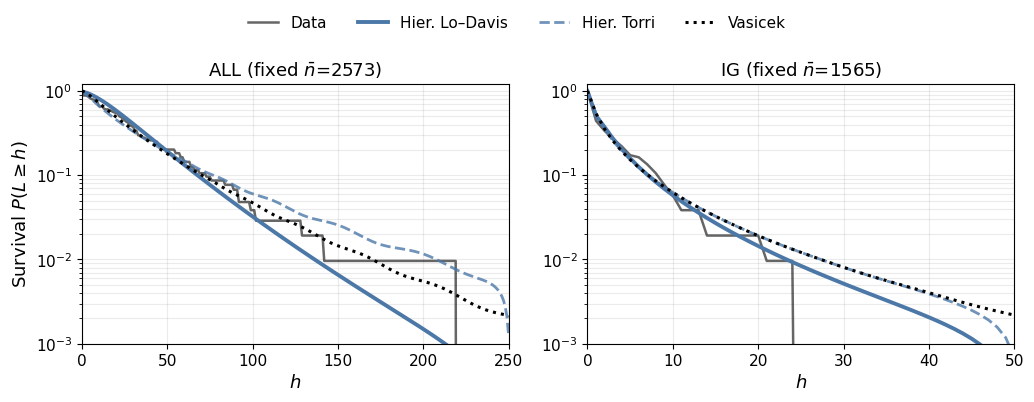

In [24]:
fits_hier_ld = {
    "ALL": out_all_hier_ld,
    "SG":  out_sg_hier_ld,
    "IG":  out_ig_hier_ld,
}

fits_hier_torri = {
    "ALL": out_all_hier_torri,
    "SG":  out_sg_hier_torri,
    "IG":  out_ig_hier_torri,
}

def model_pmf_fixed_n_hierarchical(model, key, nbar, hmax):
    if model == "LD":
        fit = fits_hier_ld[key]
        mu = float(fit["mu"])
        sigma = float(fit["sigma"])
        q_param = float(fit["q"])
        GH_N = int(fit["GH_N"])

    elif model == "Torri":
        fit = fits_hier_torri[key]
        mu = float(fit["mu"])
        sigma = float(fit["sigma"])
        u = float(fit["u"])
        v = float(fit["v"])
        GH_N = int(fit["GH_N"])

    else:
        raise ValueError("model must be 'LD' or 'Torri'")

    x, w = hermgauss(GH_N)
    y_nodes = mu + math.sqrt(2.0) * sigma * x
    w_nodes = w / math.sqrt(math.pi)
    w_nodes = w_nodes / np.sum(w_nodes)

    p_nodes = np.clip(norm.cdf(y_nodes), 1e-15, 1 - 1e-15)

    h = np.arange(hmax + 1, dtype=int)
    mix = np.zeros(hmax + 1, dtype=float)

    for pj, wj in zip(p_nodes, w_nodes):
        if model == "LD":
            lp = np.array(
                [log_pmf_LD_1pt(int(nbar), int(xx), float(pj), float(q_param)) for xx in h],
                dtype=float
            )
        else:
            lp = np.array(
                [log_pmf_Torri(int(nbar), int(xx), float(pj), float(u), float(v)) for xx in h],
                dtype=float
            )

        pmf = normalize_logpmf(lp)
        mix += wj * pmf

    mix = np.maximum(mix, 0.0)
    mix /= mix.sum()
    return mix

mpl.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 13,
    "axes.titlesize": 13,
    "legend.fontsize": 11,
    "lines.linewidth": 2.2,
    "savefig.dpi": 300,
})

# NBAR includes SG
NBAR = {
    "ALL": 2573,
    "SG":  1008,
    "IG":  1565,
}

style = {
    "Data":  {"color": "black",   "ls": "-",  "lw": 1.8, "alpha": 0.6},
    "LD":    {"color": "#4C78A8", "ls": "-",  "lw": 2.8},
    "Torri": {"color": "#4C78A8", "ls": "--", "lw": 2.0, "alpha": 0.8},
    "Vas":   {"color": "black",   "ls": ":",  "lw": 2.2},
}

# Plot range by class
HMAX_MAP = {
    "ALL": 250,
    "SG":  130,
    "IG":   50,
}

XLIM_MAP = {
    "ALL": (0, 250),
    "SG":  (0, 130),
    "IG":  (0, 50),
}

YLIM_MAP = {
    "ALL": (1e-3, 1.2),
    "SG":  (1e-3, 1.2),
    "IG":  (1e-3, 1.2),
}

def plot_survival_hier_one(ax, key, show_legend=True):
    nbar = int(NBAR[key])
    n_vals = df[key].astype(int).values
    L_vals = df["D_" + key].astype(int).values

    hmax = int(HMAX_MAP[key])
    h = np.arange(hmax + 1)

    # Data (scaled)
    Ls = scaled_counts(n_vals, L_vals, nbar)
    hist, _ = np.histogram(Ls, bins=np.arange(hmax + 2) - 0.5, density=True)
    pmf_data = np.maximum(hist, 0.0)
    pmf_data /= pmf_data.sum()
    S_data = survival_from_pmf(pmf_data)

    # Hierarchical LD
    pmf_ld = model_pmf_fixed_n_hierarchical("LD", key, nbar, hmax)
    S_ld = survival_from_pmf(pmf_ld)

    # Hierarchical Torri
    pmf_t = model_pmf_fixed_n_hierarchical("Torri", key, nbar, hmax)
    S_t = survival_from_pmf(pmf_t)

    # Vasicek benchmark
    pmf_v = pmf_vas_fixed_n(nbar, fits_vas[key]["p"], fits_vas[key]["rho_A"])
    S_v = survival_from_pmf(pmf_v)
    h_v = np.arange(len(pmf_v))

    eps = 1e-12

    ax.plot(h, np.maximum(S_data, eps), label="Data",            **style["Data"])
    ax.plot(h, np.maximum(S_ld, eps),   label="Hier. Lo–Davis",  **style["LD"])
    ax.plot(h, np.maximum(S_t, eps),    label="Hier. Torri",     **style["Torri"])
    ax.plot(h_v, np.maximum(S_v, eps),    label="Vasicek",         **style["Vas"])

    ax.set_yscale("log")
    ax.set_title(f"{key} (fixed $\\bar{{n}}$={nbar})")
    ax.set_xlabel(r"$h$")
    ax.set_ylabel(r"Survival $P(L \geq h)$")
    ax.grid(alpha=0.25, which="both")

    ax.set_xlim(*XLIM_MAP[key])
    ax.set_ylim(*YLIM_MAP[key])

    if show_legend:
        ax.legend(frameon=False, loc="upper right")

# ==========================================
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(10.5, 4))

for ax, key in zip(axes, ["ALL", "IG"]):
    plot_survival_hier_one(ax, key, show_legend=False)

# Keep the y-label on the left panel only
axes[1].set_ylabel("")

# Shared legend
handles, labels = axes[0].get_legend_handles_labels()
order = ["Data", "Hier. Lo–Davis", "Hier. Torri", "Vasicek"]
handles_dict = dict(zip(labels, handles))
ordered_handles = [handles_dict[k] for k in order if k in handles_dict]

fig.legend(
    ordered_handles,
    order,
    loc="upper center",
    ncol=4,
    frameon=False,
    bbox_to_anchor=(0.5, 1.02)
)

plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.savefig("figure5_survival_hierarchical_ALL_IG.pdf", bbox_inches="tight")
plt.show()

## Figure generation
Generate the comparison figures used in the analysis.

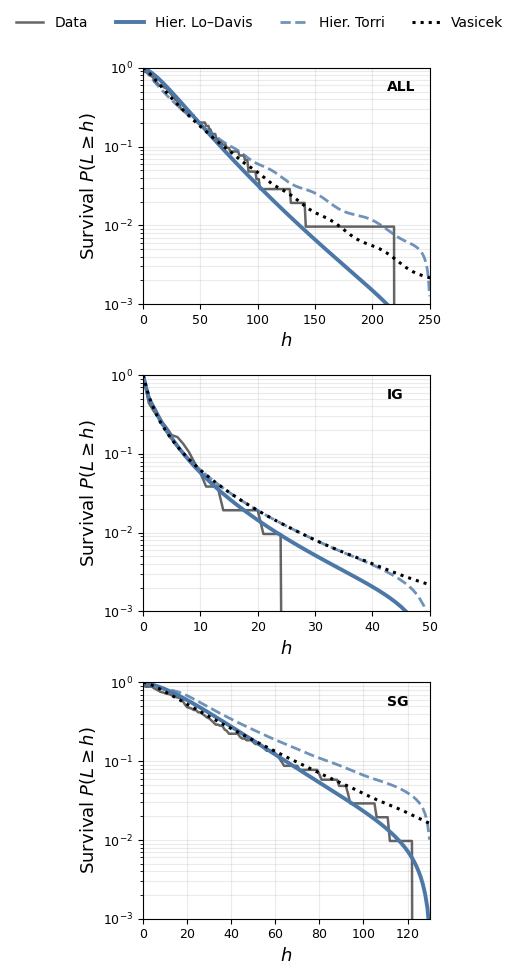

In [25]:
# ==========================================
# Survival: ALL + IG + SG (stacked)
# ==========================================
fig, axes = plt.subplots(3, 1, figsize=(4, 10))

labels_map = {"ALL": "ALL", "IG": "IG", "SG": "SG"}

for ax, key in zip(axes, ["ALL", "IG", "SG"]):
    plot_survival_hier_one(ax, key, show_legend=False)

    ax.set_title("")

    ax.text(
        0.85, 0.90,
        labels_map[key],
        transform=ax.transAxes,
        fontsize=10,
        fontweight="bold"
    )
    ax.set_ylim(1e-3, 1)
    ax.tick_params(labelsize=9)

# Legend (top)
handles, labels = axes[0].get_legend_handles_labels()
order = ["Data", "Hier. Lo–Davis", "Hier. Torri", "Vasicek"]
handles_dict = dict(zip(labels, handles))
ordered_handles = [handles_dict[k] for k in order if k in handles_dict]

fig.legend(
    ordered_handles,
    order,
    loc="upper center",
    ncol=4,
    frameon=False,
    bbox_to_anchor=(0.5, 0.98),
    fontsize=10
)

# Layout
plt.subplots_adjust(hspace=0.25)
plt.tight_layout(rect=[0, 0, 1, 0.94])

plt.savefig("figure9b_survival_hier_ALLCLASS.pdf", bbox_inches="tight")
plt.show()

## Plot style
Set plotting defaults for paper-style figures.

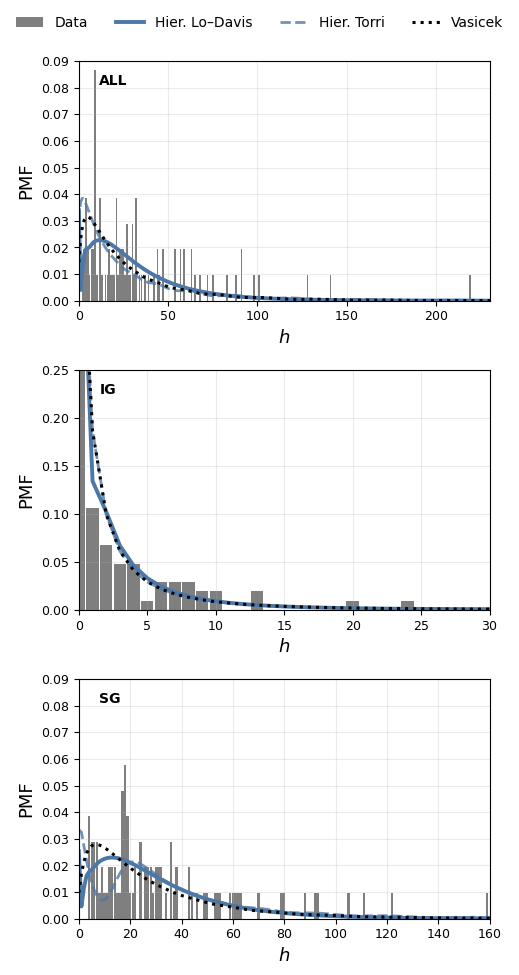

In [26]:
# ==========================================
# PMF (hierarchical models)
#   - Data (scaled)
#   - Hierarchical Lo–Davis
#   - Hierarchical Torri
#   - Vasicek
#        ALL + IG

# ==========================================

mpl.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 13,
    "axes.titlesize": 13,
    "legend.fontsize": 11,
    "lines.linewidth": 2.2,
    "savefig.dpi": 300,
})

NBAR = {
    "ALL": 2573,
    "SG":  1008,
    "IG":  1565,
}

# Plot range
HMAX_MAP = {
    "ALL": 300,
    "SG":  300,
    "IG":   40,
}

XLIM_MAP = {
    "ALL": (0, 230),
    "SG":  (0, 160),
    "IG":  (0, 30),
}

YLIM_MAP = {
    "ALL": (0, 0.09),
    "SG":  (0, 0.09),
    "IG":  (0, 0.25),
}

style = {
    "Data":  {"color": "black",   "alpha": 0.5},
    "LD":    {"color": "#4C78A8", "lw": 2.8},
    "Torri": {"color": "#4C78A8", "lw": 2.0, "ls": "--", "alpha": 0.8},
    "Vas":   {"color": "black",   "lw": 2.2, "ls": ":"},
}

# ==========================================
# helper: PMF plot
# ==========================================
def plot_pmf_hier_one(ax, key, show_legend=True):
    nbar = int(NBAR[key])
    n_vals = df[key].astype(int).values
    L_vals = df["D_" + key].astype(int).values

    hmax = int(HMAX_MAP[key])
    h = np.arange(hmax + 1)

    # -----------------------------
    # Data (scaled)
    # -----------------------------
    Ls = scaled_counts(n_vals, L_vals, nbar)
    hist, _ = np.histogram(Ls, bins=np.arange(hmax + 2) - 0.5, density=True)

    ax.bar(h, hist, width=0.9, label="Data", **style["Data"], zorder=1)

    # -----------------------------
    # Hierarchical LD
    # -----------------------------
    pmf_ld = model_pmf_fixed_n_hierarchical("LD", key, nbar, hmax)

    # -----------------------------
    # Hierarchical Torri
    # -----------------------------
    pmf_t = model_pmf_fixed_n_hierarchical("Torri", key, nbar, hmax)

    # -----------------------------
    # Vasicek
    # -----------------------------
    pmf_v = pmf_vas_fixed_n(nbar, fits_vas[key]["p"], fits_vas[key]["rho_A"])
    h_v = np.arange(len(pmf_v))
  

    ax.plot(h, pmf_ld, label="Hier. Lo–Davis", **style["LD"])
    ax.plot(h, pmf_t,  label="Hier. Torri",   **style["Torri"])
    ax.plot(h_v, pmf_v,  label="Vasicek",       **style["Vas"])

    ax.set_title(f"{key} (fixed $\\bar{{n}}$={nbar})")
    ax.set_xlabel(r"$h$")
    ax.set_ylabel("PMF")
    ax.grid(alpha=0.25)

    ax.set_xlim(*XLIM_MAP[key])
    ax.set_ylim(*YLIM_MAP[key])

    if show_legend:
        ax.legend(frameon=False)

# ==========================================
# PMF: ALL + IG + SG (stacked)
# ==========================================
fig, axes = plt.subplots(3, 1, figsize=(5.2, 10))

labels_map = {"ALL": "ALL", "IG": "IG", "SG": "SG"}

for ax, key in zip(axes, ["ALL", "IG", "SG"]):
    plot_pmf_hier_one(ax, key, show_legend=False)
    ax.set_title("")   # keep panel titles empty

    ax.text(
        0.05, 0.90,
        labels_map[key],
        transform=ax.transAxes,
        fontsize=10,
        fontweight="bold"
    )

    ax.tick_params(labelsize=9)

# Collect the legend at the top
handles, labels = axes[0].get_legend_handles_labels()
order = ["Data", "Hier. Lo–Davis", "Hier. Torri", "Vasicek"]
handles_dict = dict(zip(labels, handles))
ordered_handles = [handles_dict[k] for k in order if k in handles_dict]

fig.legend(
    ordered_handles,
    order,
    loc="upper center",
    ncol=4,
    frameon=False,
    bbox_to_anchor=(0.5, 0.98),
    fontsize=10
)

# Layout
plt.subplots_adjust(hspace=0.25)
plt.tight_layout(rect=[0, 0, 1, 0.94])

plt.savefig("figure9a_pmf_hier_ALLCLASS.pdf", bbox_inches="tight")
plt.show()

## Hierarchical model PMFs
Construct fixed-*n* predictive distributions under the hierarchical specification.

In [27]:
def model_pmf_fixed_n_hierarchical_full(model, key, nbar):
    return model_pmf_fixed_n_hierarchical(model, key, nbar, nbar)

for key in ["ALL", "SG"]:
    nbar = int(NBAR[key])
    pmf_t_full = model_pmf_fixed_n_hierarchical_full("Torri", key, nbar)
    print(key, "tail mass beyond hmax =", pmf_t_full[HMAX_MAP[key]+1:].sum())
    print(key, "pmf at hmax-2:hmax+3 =", pmf_t_full[HMAX_MAP[key]-2:HMAX_MAP[key]+3])

ALL tail mass beyond hmax = 0.0023341437416467816
ALL pmf at hmax-2:hmax+3 = [1.94768396e-05 1.76314101e-05 1.59649810e-05 1.44757399e-05
 1.31607591e-05]
SG tail mass beyond hmax = 0.0010975743804316207
SG pmf at hmax-2:hmax+3 = [3.31265840e-05 3.16484760e-05 3.00997781e-05 2.84995856e-05
 2.68668855e-05]


## Variance decomposition
Decompose empirical variance into model-implied components.

In [28]:
# ============================================================
# Subsample analysis: 1950-1979 / 1980-2023
# Reuses existing functions already defined in this notebook.
# ============================================================

# ----------------------------
# 0) configuration
# ----------------------------
PERIODS = {
    "1950_1979": (1950, 1979),
    "1980_2023": (1980, 2023),
}

CLASSES = ["ALL", "SG", "IG"]

ALPHAS = [0.95, 0.99]
GH_N_HIER = 100
MAXITER_IID = 8000
MAXITER_HIER = 6000

# ----------------------------
# 1) small utilities
# ----------------------------
def subset_df_by_period(df, start_year, end_year):
    out = df[(df["Year"] >= start_year) & (df["Year"] <= end_year)].copy()
    out = out.reset_index(drop=True)
    return out

def compute_nbar_for_period(df_sub, classes=("ALL", "SG", "IG")):
    nbar = {}
    for key in classes:
        vals = pd.to_numeric(df_sub[key], errors="coerce").dropna().to_numpy()
        nbar[key] = int(np.rint(np.mean(vals)))
    return nbar

def build_iid_fit_dicts(period_fit_results):
    fits_torri = {}
    fits_ld = {}
    fits_vas = {}
    for key in CLASSES:
        fits_torri[key] = {
            "p": float(period_fit_results["iid"]["Torri"][key]["p"]),
            "u": float(period_fit_results["iid"]["Torri"][key]["u"]),
            "v": float(period_fit_results["iid"]["Torri"][key]["v"]),
        }
        fits_ld[key] = {
            "p": float(period_fit_results["iid"]["LD"][key]["p"]),
            "q": float(period_fit_results["iid"]["LD"][key]["q"]),
        }
        fits_vas[key] = {
            "p": float(period_fit_results["iid"]["Vasicek"][key]["p"]),
            "rho_A": float(period_fit_results["iid"]["Vasicek"][key]["rho_A"]),
        }
    return fits_torri, fits_ld, fits_vas

def build_hier_fit_dicts(period_fit_results):
    fits_hier_ld = {}
    fits_hier_torri = {}
    for key in CLASSES:
        fits_hier_ld[key] = {
            "mu": float(period_fit_results["hier"]["LD"][key]["mu"]),
            "sigma": float(period_fit_results["hier"]["LD"][key]["sigma"]),
            "q": float(period_fit_results["hier"]["LD"][key]["q"]),
            "GH_N": int(period_fit_results["hier"]["LD"][key]["GH_N"]),
        }
        fits_hier_torri[key] = {
            "mu": float(period_fit_results["hier"]["Torri"][key]["mu"]),
            "sigma": float(period_fit_results["hier"]["Torri"][key]["sigma"]),
            "u": float(period_fit_results["hier"]["Torri"][key]["u"]),
            "v": float(period_fit_results["hier"]["Torri"][key]["v"]),
            "GH_N": int(period_fit_results["hier"]["Torri"][key]["GH_N"]),
        }
    return fits_hier_ld, fits_hier_torri
def run_iid_fits_for_period(df_sub):
    out = {"Torri": {}, "LD": {}, "Vasicek": {}}

    for key in CLASSES:
        out["Torri"][key] = fit_one_Torri(df_sub[key], df_sub["D_" + key], maxiter=MAXITER_IID)
        out["LD"][key] = fit_one_LD(df_sub[key], df_sub["D_" + key])
        out["Vasicek"][key] = fit_one_Vas(df_sub[key], df_sub["D_" + key], maxiter=MAXITER_IID)

    rows = []
    for model in ["Torri", "LD", "Vasicek"]:
        for key in CLASSES:
            fit = out[model][key]
            row = {
                "model": model,
                "class": key,
                "nll": float(fit["nll"]),
                "success": bool(fit["success"]),
                "nit": int(fit["nit"]),
                "message": str(fit["message"]),
            }
            for par in ["p", "u", "v", "q", "rho_A", "GH_N"]:
                if par in fit:
                    row[par] = fit[par]
            rows.append(row)

    df_iid = pd.DataFrame(rows).sort_values(["class", "nll"]).reset_index(drop=True)
    return out, df_iid

# ----------------------------
# 3) Hierarchical fits
# ----------------------------
def run_hier_fits_for_period(df_sub, GH_N=GH_N_HIER):
    out = {"LD": {}, "Torri": {}}

    for key in CLASSES:
        out["LD"][key] = fit_one_hier_LD(
            df_sub[key], df_sub["D_" + key],
            GH_N=GH_N, maxiter=MAXITER_HIER
        )
        out["Torri"][key] = fit_one_hier_Torri(
            df_sub[key], df_sub["D_" + key],
            GH_N=GH_N, maxiter=MAXITER_HIER
        )

    rows = []
    for model in ["LD", "Torri"]:
        for key in CLASSES:
            fit = out[model][key]
            row = {
                "model": f"Hier-{model}",
                "class": key,
                "nll": float(fit["nll"]),
                "success": bool(fit["success"]),
                "nit": int(fit["nit"]),
                "message": str(fit["message"]),
            }
            for par in ["mu", "sigma", "q", "u", "v", "GH_N"]:
                if par in fit:
                    row[par] = fit[par]
            rows.append(row)

    df_hier = pd.DataFrame(rows).sort_values(["class", "nll"]).reset_index(drop=True)
    return out, df_hier

# ----------------------------
# 4) variance decomposition
#    Vasicek version added here
# ----------------------------
def variance_decomp_vas_fixed_nbar(df, NBAR, fits_vas, keys=("ALL", "SG", "IG")):
    rows = []

    for key in keys:
        nbar = int(NBAR[key])

        n_vals, L_vals = _clean_nL(df, key)
        L_scaled = scaled_counts(n_vals, L_vals, nbar)

        var_data_scaled = float(np.var(L_scaled, ddof=1)) if len(L_scaled) >= 2 else np.nan
        m_hat_data = float(np.sum(L_vals) / np.sum(n_vals))
        var_iid_data_scaled = float(nbar * m_hat_data * (1.0 - m_hat_data))
        var_corr_data_scaled = (
            var_data_scaled - var_iid_data_scaled
            if np.isfinite(var_data_scaled) else np.nan
        )

        p = float(fits_vas[key]["p"])
        rho_A = float(fits_vas[key]["rho_A"])

        a = norm.ppf(np.clip(p, 1e-15, 1.0 - 1e-15))
        q_bar = float(phi2_aa(a, rho_A))
        rho_bar = aggregate_m_q_to_rho(p, q_bar)

        var_iid_model = float(nbar * p * (1.0 - p))
        var_factor_model = float(nbar * (nbar - 1) * (q_bar - p**2))
        var_model_total = var_iid_model + var_factor_model

        rows.append({
            "class": key,
            "nbar": nbar,
            "p": p,
            "rho_A": rho_A,
            "Var_data_scaled": var_data_scaled,
            "m_hat_data": m_hat_data,
            "Var_iid_data_scaled": var_iid_data_scaled,
            "Var_corr_data_scaled": var_corr_data_scaled,
            "m_bar_model": p,
            "q_bar_model": q_bar,
            "rho_bar_model": rho_bar,
            "Var_iid_model": var_iid_model,
            "Var_factor_model": var_factor_model,
            "Var_model_total": var_model_total,
            "Share_iid_within_model": (var_iid_model / var_model_total) if var_model_total > 0 else np.nan,
            "Share_factor_within_model": (var_factor_model / var_model_total) if var_model_total > 0 else np.nan,
            "Iid_over_VarData": (var_iid_model / var_data_scaled) if (np.isfinite(var_data_scaled) and var_data_scaled > 0) else np.nan,
            "Factor_over_VarData": (var_factor_model / var_data_scaled) if (np.isfinite(var_data_scaled) and var_data_scaled > 0) else np.nan,
        })

    return pd.DataFrame(rows)

def build_compare_decomp_table_with_vas(out_var_hier_ld, out_var_hier_torri, out_var_vas):
    cols_common = ["class", "Iid_over_VarData"]

    df_ld = out_var_hier_ld[[
        "class",
        "Share_iid_within_model",
        "Share_infect_within_model",
        "Share_pt_within_model",
        "Iid_over_VarData",
        "Infect_over_VarData",
        "Pt_over_VarData",
    ]].copy()
    df_ld["model"] = "Hier-Lo–Davis"

    df_t = out_var_hier_torri[[
        "class",
        "Share_iid_within_model",
        "Share_infect_within_model",
        "Share_pt_within_model",
        "Iid_over_VarData",
        "Infect_over_VarData",
        "Pt_over_VarData",
    ]].copy()
    df_t["model"] = "Hier-Torri"

    df_v = out_var_vas[[
        "class",
        "Share_iid_within_model",
        "Share_factor_within_model",
        "Iid_over_VarData",
        "Factor_over_VarData",
    ]].copy()
    df_v["model"] = "Vasicek"

    return pd.concat([df_ld, df_t, df_v], axis=0, ignore_index=True).sort_values(["class", "model"]).reset_index(drop=True)

# ----------------------------
# 5) PMFs for tail comparison
# ----------------------------

def pmf_iid_ld_fixed_n(nbar, p, q_param):
    h = np.arange(nbar + 1, dtype=int)
    lp = np.array(
        [log_pmf_LD_1pt(int(nbar), int(x), float(p), float(q_param)) for x in h],
        dtype=float
    )
    return normalize_logpmf(lp)

def pmf_iid_torri_fixed_n(nbar, p, u, v):
    h = np.arange(nbar + 1, dtype=int)
    lp = np.array(
        [log_pmf_Torri(int(nbar), int(x), float(p), float(u), float(v)) for x in h],
        dtype=float
    )
    return normalize_logpmf(lp)
def compute_tail_table_for_period(
    df_sub,
    iid_fit_results,
    hier_fit_results,
    NBAR,
    alphas=(0.95, 0.99),
):
    fits_torri, fits_ld, fits_vas = build_iid_fit_dicts({"iid": iid_fit_results})
    fits_hier_ld, fits_hier_torri = build_hier_fit_dicts({"hier": hier_fit_results})

    rows = []

    for key in CLASSES:
        nbar = int(NBAR[key])

        n_vals = df_sub[key].astype(int).values
        L_vals = df_sub["D_" + key].astype(int).values
        L_scaled = scaled_counts(n_vals, L_vals, nbar)

        _, pmf_data = empirical_pmf_from_counts(L_scaled)
        pmf_data_full = np.zeros(nbar + 1, dtype=float)
        pmf_data_full[:len(pmf_data)] = pmf_data

        pmf_v = pmf_vas_fixed_n(nbar, fits_vas[key]["p"], fits_vas[key]["rho_A"])
        pmf_iid_ld = pmf_iid_ld_fixed_n(nbar, fits_ld[key]["p"], fits_ld[key]["q"])
        pmf_iid_t = pmf_iid_torri_fixed_n(nbar, fits_torri[key]["p"], fits_torri[key]["u"], fits_torri[key]["v"])
        pmf_hld = pmf_hier_ld_fixed_n(
            nbar,
            fits_hier_ld[key]["mu"],
            fits_hier_ld[key]["sigma"],
            fits_hier_ld[key]["q"],
            fits_hier_ld[key]["GH_N"],
        )
        pmf_ht = pmf_hier_torri_fixed_n(
            nbar,
            fits_hier_torri[key]["mu"],
            fits_hier_torri[key]["sigma"],
            fits_hier_torri[key]["u"],
            fits_hier_torri[key]["v"],
            fits_hier_torri[key]["GH_N"],
        )

        model_pmfs = [
            ("Data(scaled)", pmf_data_full),
            ("IID-Vasicek", pmf_v),
            ("IID-Lo–Davis", pmf_iid_ld),
            ("IID-Torri", pmf_iid_t),
            ("Hier-Lo–Davis", pmf_hld),
            ("Hier-Torri", pmf_ht),
        ]

        for alpha in alphas:
            for model_name, pmf in model_pmfs:
                met = tail_metrics_from_pmf(pmf, alpha=alpha, strict_es=False)
                rows.append({
                    "class": key,
                    "alpha": alpha,
                    "model": model_name,
                    "VaR": met["VaR"],
                    "ES": met["ES"],
                    "ES_minus_VaR": met["ES_minus_VaR"],
                    "ES_over_VaR": met["ES_over_VaR"],
                })

    return pd.DataFrame(rows).sort_values(["class", "alpha", "model"]).reset_index(drop=True)

# ----------------------------
# 7) master runner
# ----------------------------
def run_period_analysis(df, period_name, start_year, end_year):
    df_sub = subset_df_by_period(df, start_year, end_year)
    NBAR = compute_nbar_for_period(df_sub, CLASSES)

    print(f"\n===== {period_name}: {start_year}-{end_year} =====")
    print(f"N_years = {len(df_sub)}")
    print(f"NBAR = {NBAR}")

    # IID
    iid_fit_results, df_iid = run_iid_fits_for_period(df_sub)

    # Hierarchical
    hier_fit_results, df_hier = run_hier_fits_for_period(df_sub, GH_N=GH_N_HIER)

    # Build dicts
    fits_torri, fits_ld, fits_vas = build_iid_fit_dicts({"iid": iid_fit_results})
    fits_hier_ld, fits_hier_torri = build_hier_fit_dicts({"hier": hier_fit_results})

    # Variance decomposition
    out_var_hier_ld = variance_decomp_hier_ld_fixed_nbar(
        df_sub, NBAR, fits_hier_ld, CLASSES
    )

    out_var_hier_torri = variance_decomp_hier_torri_fixed_nbar(
        df_sub, NBAR, fits_hier_torri, CLASSES
    )

    out_var_vas = variance_decomp_vas_fixed_nbar(
        df_sub, NBAR, fits_vas, CLASSES
    )

    df_var_compare = build_compare_decomp_table_with_vas(
        out_var_hier_ld,
        out_var_hier_torri,
        out_var_vas,
    )

    # Tail table
    df_tail = compute_tail_table_for_period(
        df_sub=df_sub,
        iid_fit_results=iid_fit_results,
        hier_fit_results=hier_fit_results,
        NBAR=NBAR,
        alphas=ALPHAS,
    )

    return {
        "df_sub": df_sub,
        "NBAR": NBAR,
        "iid_fit_results": iid_fit_results,
        "hier_fit_results": hier_fit_results,
        "iid_fit_table": df_iid,
        "hier_fit_table": df_hier,
        "var_hier_ld": out_var_hier_ld,
        "var_hier_torri": out_var_hier_torri,
        "var_vas": out_var_vas,
        "var_compare": df_var_compare,
        "tail_table": df_tail,
    }

# ----------------------------
# 8) run all periods
# ----------------------------
PERIOD_RESULTS = {}

for pname, (y0, y1) in PERIODS.items():
    PERIOD_RESULTS[pname] = run_period_analysis(df, pname, y0, y1)

# ----------------------------
# 9) display
# ----------------------------
for pname in PERIODS.keys():
    print("\n" + "=" * 80)
    print(f"[{pname}] IID fit table")
    display(PERIOD_RESULTS[pname]["iid_fit_table"].round(6))

    print(f"\n[{pname}] Hierarchical fit table")
    display(PERIOD_RESULTS[pname]["hier_fit_table"].round(6))

    print(f"\n[{pname}] Variance decomposition: Hier-Lo–Davis / Hier-Torri / Vasicek")
    display(PERIOD_RESULTS[pname]["var_compare"].round(6))

    print(f"\n[{pname}] Tail table")
    display(PERIOD_RESULTS[pname]["tail_table"].round(6))

# ----------------------------
# 10) optional: compact summaries
# ----------------------------
def compact_nll_summary(period_results):
    rows = []
    for pname, res in period_results.items():
        tmp1 = res["iid_fit_table"][["class", "model", "nll"]].copy()
        tmp1["period"] = pname
        tmp1["type"] = "IID"

        tmp2 = res["hier_fit_table"][["class", "model", "nll"]].copy()
        tmp2["period"] = pname
        tmp2["type"] = "Hier"

        rows.append(tmp1)
        rows.append(tmp2)

    out = pd.concat(rows, axis=0, ignore_index=True)
    return out[["period", "type", "class", "model", "nll"]].sort_values(
        ["period", "type", "class", "nll"]
    ).reset_index(drop=True)

df_nll_summary = compact_nll_summary(PERIOD_RESULTS)
print("\n[Compact NLL summary]")
display(df_nll_summary.round(6))


===== 1950_1979: 1950-1979 =====
N_years = 30
NBAR = {'ALL': 860, 'SG': 240, 'IG': 620}

===== 1980_2023: 1980-2023 =====
N_years = 44
NBAR = {'ALL': 4276, 'SG': 1678, 'IG': 2598}

[1950_1979] IID fit table


,model,class,nll,success,nit,message,p,u,v,q,rho_A,GH_N
0,Vasicek,ALL,58.2442,True,37,Optimization terminated successfully.,0.002548,NaN,NaN,NaN,0.098216,100
1,LD,ALL,63.5695,True,45,Optimization terminated successfully.,0.001294,NaN,NaN,0.001322,NaN,NaN
2,Torri,ALL,90.0123,True,134,Optimization terminated successfully.,0.002945,4.2e-05,0,NaN,NaN,NaN
3,LD,IG,11.8125,True,45,Optimization terminated successfully.,0.000168,NaN,NaN,0.000721,NaN,NaN
4,Vasicek,IG,12.9056,True,50,Optimization terminated successfully.,0.00026,NaN,NaN,NaN,0.168325,100
5,Torri,IG,13.9581,True,146,Optimization terminated successfully.,0.000269,0.426362,0,NaN,NaN,NaN
6,Torri,SG,57.268,True,79,Optimization terminated successfully.,0.006795,0.922582,0.020855,NaN,NaN,NaN
7,Vasicek,SG,58.8513,True,36,Optimization terminated successfully.,0.009049,NaN,NaN,NaN,0.144161,100
8,LD,SG,64.1407,True,37,Optimization terminated successfully.,0.004447,NaN,NaN,0.004943,NaN,NaN



[1950_1979] Hierarchical fit table


,model,class,nll,success,nit,message,mu,sigma,q,GH_N,u,v
0,Hier-LD,ALL,58.1637,True,234,Optimization terminated successfully.,-2.9746,0.309203,0.000151,100,NaN,NaN
1,Hier-Torri,ALL,58.2442,True,261,Optimization terminated successfully.,-2.94954,0.330017,NaN,100,0.778595,0
2,Hier-Torri,IG,11.7179,True,481,Optimization terminated successfully.,-3.57834,1e-06,NaN,100,0.999288,1
3,Hier-LD,IG,11.8125,True,214,Optimization terminated successfully.,-3.58605,0,0.000721,100,NaN,NaN
4,Hier-Torri,SG,55.9583,True,143,Optimization terminated successfully.,-2.52057,0.214546,NaN,100,0.924518,0.02073
5,Hier-LD,SG,58.8388,True,101,Optimization terminated successfully.,-2.56651,0.397183,0.00025,100,NaN,NaN



[1950_1979] Variance decomposition: Hier-Lo–Davis / Hier-Torri / Vasicek


...

,class,Share_iid_within_model,Share_infect_within_model,Share_pt_within_model,Iid_over_VarData,Infect_over_VarData,Pt_over_VarData,model,Share_factor_within_model,Factor_over_VarData
0,ALL,0.038954,0.047216,0.913831,0.034952,0.042365,0.819943,Hier-Lo–Davis,NaN,NaN
1,ALL,0.035972,5.9e-05,0.963969,0.034923,5.7e-05,0.935859,Hier-Torri,NaN,NaN
2,ALL,0.036201,NaN,NaN,0.035141,NaN,NaN,Vasicek,0.963799,0.935603
3,IG,0.143527,0.151759,0.704714,0.167083,0.176666,0.820373,Hier-Lo–Davis,NaN,NaN
4,IG,0.086542,0,0.913458,0.179717,0,1.89693,Hier-Torri,NaN,NaN
5,IG,0.086891,NaN,NaN,0.180445,NaN,NaN,Vasicek,0.913109,1.89623
6,SG,0.040576,-0,0.959424,0.036475,-0,0.862465,Hier-Lo–Davis,NaN,NaN
7,SG,0.040576,0,0.959424,0.036475,0,0.862465,Hier-Torri,NaN,NaN
8,SG,0.041142,NaN,NaN,0.036989,NaN,NaN,Vasicek,0.958858,0.862056



[1980_2023] Tail table


,class,alpha,model,VaR,ES,ES_minus_VaR,ES_over_VaR
0,ALL,0.95,Data(scaled),151,171.667,20.6667,1.13687
1,ALL,0.95,Hier-Lo–Davis,146,181.959,35.9587,1.24629
2,ALL,0.95,Hier-Torri,149,187.69,38.6901,1.25967
3,ALL,0.95,IID-Lo–Davis,128,146.752,18.7518,1.1465
4,ALL,0.95,IID-Torri,123,127.918,4.91836,1.03999
5,ALL,0.95,IID-Vasicek,149,187.69,38.6902,1.25967
6,ALL,0.99,Data(scaled),213,213,0,1
7,ALL,0.99,Hier-Lo–Davis,204,240.87,36.8705,1.18074
8,ALL,0.99,Hier-Torri,212,251.769,39.7686,1.18759
9,ALL,0.99,IID-Lo–Davis,160,176.028,16.0283,1.10018



[Compact NLL summary]


,period,type,class,model,nll
0,1950_1979,Hier,ALL,Hier-LD,58.1637
1,1950_1979,Hier,ALL,Hier-Torri,58.2442
2,1950_1979,Hier,IG,Hier-Torri,11.7179
3,1950_1979,Hier,IG,Hier-LD,11.8125
4,1950_1979,Hier,SG,Hier-Torri,55.9583
5,1950_1979,Hier,SG,Hier-LD,58.8388
6,1950_1979,IID,ALL,Vasicek,58.2442
7,1950_1979,IID,ALL,LD,63.5695
8,1950_1979,IID,ALL,Torri,90.0123
9,1950_1979,IID,IG,LD,11.8125


## Figure generation
Generate the comparison figures used in the analysis.

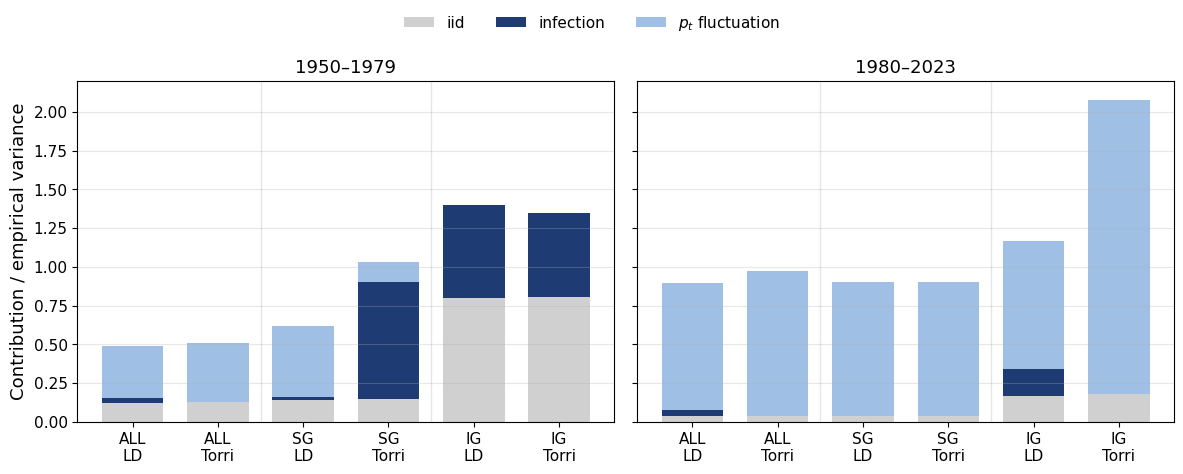

In [29]:
# ============================================================
# Final summary figure (paper style: blue + grayscale)
# Two-period comparison: 1950–79 vs 1980–23
# ============================================================

# ------------------------------------------------------------
# 1. Build tidy tables for both periods
# ------------------------------------------------------------
df_pre  = build_compare_decomp_table(
    PERIOD_RESULTS["1950_1979"]["var_hier_ld"],
    PERIOD_RESULTS["1950_1979"]["var_hier_torri"]
)

df_post = build_compare_decomp_table(
    PERIOD_RESULTS["1980_2023"]["var_hier_ld"],
    PERIOD_RESULTS["1980_2023"]["var_hier_torri"]
)

# ------------------------------------------------------------
# 2. Prepare plotting data function
# ------------------------------------------------------------
def prepare_plot_data(df_cmp_decomp):
    classes = ["ALL", "SG", "IG"]
    models = ["Lo–Davis", "Torri"]

    labels = []
    iid_vals = []
    inf_vals = []
    pt_vals = []

    for c in classes:
        for m in models:
            sub = df_cmp_decomp[
                (df_cmp_decomp["class"] == c) &
                (df_cmp_decomp["model"] == m)
            ]

            labels.append(f"{c}\n{'LD' if m == 'Lo–Davis' else 'Torri'}")

            iid_vals.append(sub["Iid_over_VarData"].values[0])
            inf_vals.append(sub["Infect_over_VarData"].values[0])
            pt_vals.append(sub["Pt_over_VarData"].values[0])

    return (
        labels,
        np.array(iid_vals),
        np.array(inf_vals),
        np.array(pt_vals)
    )

labels_pre, iid_pre, inf_pre, pt_pre   = prepare_plot_data(df_pre)
labels_post, iid_post, inf_post, pt_post = prepare_plot_data(df_post)

x = np.arange(len(labels_pre))
width = 0.72

# ------------------------------------------------------------
# 3. Paper-style colors
# ------------------------------------------------------------
c_iid = "#D0D0D0"   # light gray
c_pt  = "#9FBFE5"   # light blue
c_inf = "#1F3B73"   # dark blue

# ------------------------------------------------------------
# 4. Plot (two panels)
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), sharey=True)

# ---------- Left: 1950–1979 ----------
ax = axes[0]

ax.bar(x, iid_pre, width=width, color=c_iid)
ax.bar(x, inf_pre, width=width, bottom=iid_pre, color=c_inf)
ax.bar(x, pt_pre,  width=width, bottom=iid_pre + inf_pre, color=c_pt)

for pos in [1.5, 3.5]:
    ax.axvline(pos, color="gray", alpha=0.2, linewidth=1)

ax.set_xticks(x)
ax.set_xticklabels(labels_pre)
ax.set_title("1950–1979")
ax.set_ylabel("Contribution / empirical variance")
ax.set_ylim(0, 2.2)
ax.grid(axis="y", alpha=0.3)

# ---------- Right: 1980–2023 ----------
ax = axes[1]

ax.bar(x, iid_post, width=width, color=c_iid, label="iid")
ax.bar(x, inf_post, width=width, bottom=iid_post, color=c_inf, label="infection")
ax.bar(x, pt_post,  width=width, bottom=iid_post + inf_post, color=c_pt, label="$p_t$ fluctuation")

for pos in [1.5, 3.5]:
    ax.axvline(pos, color="gray", alpha=0.2, linewidth=1)

ax.set_xticks(x)
ax.set_xticklabels(labels_post)
ax.set_title("1980–2023")
ax.grid(axis="y", alpha=0.3)

# ------------------------------------------------------------
# 5. Legend (shared)
# ------------------------------------------------------------
handles, labels = axes[1].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3, frameon=False)

plt.tight_layout(rect=[0, 0, 1, 0.92])

# ------------------------------------------------------------
# 6. Save
# ------------------------------------------------------------
plt.savefig("figure10_variance_decomp_two_periods.pdf", bbox_inches="tight")
plt.show()